In [190]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 140)
pd.set_option("display.width", 200)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "data" / "raw").exists() and (candidate / "theo" / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/raw and theo/data/processed.")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "theo" / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

EM_RAW_PATH = RAW_DIR / "em_fx_spot_forward_long.parquet"
G10_PANEL_PATH = PROCESSED_DIR / "g10_1m_carry_panel.parquet"
EM_PANEL_OUT = PROCESSED_DIR / "em_1m_carry_panel.parquet"
STRATEGY_RETURNS_OUT = PROCESSED_DIR / "em_carry_strategy_returns.parquet"
COMPARISON_OUT = PROCESSED_DIR / "g10_em_carry_comparison.parquet"

MONTHS_PER_YEAR = 12
ROLL_COST_BPS = [1, 2, 5, 10, 25, 50]


In [191]:
EM_CURRENCIES = ["MXN", "ZAR", "BRL", "KRW", "IDR", "MYR", "PHP", "CLP", "COP", "PEN", "SGD", "CNH", "INR", "THB", "PLN", "HUF", "TRY", "ILS"]

# Currency-specific point sizes are in raw quote units. They convert Bloomberg forward points into outright local-per-USD rates.
EM_CONFIG = {
    "MXN": {"forward_ticker": "MXN1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "ZAR": {"forward_ticker": "ZAR1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "BRL": {"forward_ticker": "BCN1M Curncy", "point_size": 0.0001, "note": "BRL NDF root BCN"},
    "KRW": {"forward_ticker": "KWO1M Curncy", "point_size": 1.0, "note": "KRW special/onshore root KWO"},
    "IDR": {"forward_ticker": "IHO1M Curncy", "point_size": 1.0, "note": "IDR special/onshore root IHO"},
    "MYR": {"forward_ticker": "MYR1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "PHP": {"forward_ticker": "PPN1M Curncy", "point_size": 1.0, "note": "PHP NDF root PPN"},
    "CLP": {"forward_ticker": "CHN1M Curncy", "point_size": 1.0, "note": "CLP NDF root CHN"},
    "COP": {"forward_ticker": "CLN1M Curncy", "point_size": 1.0, "note": "COP NDF root CLN"},
    "PEN": {"forward_ticker": "PSN1M Curncy", "point_size": 0.0001, "note": "PEN NDF root PSN"},
    "SGD": {"forward_ticker": "SGD1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "CNH": {"forward_ticker": "CNH1M Curncy", "point_size": 0.0001, "note": "CNH offshore simple forward points"},
    "INR": {"forward_ticker": "IRN1M Curncy", "point_size": 0.01, "note": "INR IRN convention used because INR1M is unavailable"},
    "THB": {"forward_ticker": "THB1M Curncy", "point_size": 0.01, "note": "simple forward points"},
    "PLN": {"forward_ticker": "PLN1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "HUF": {"forward_ticker": "HUF1M Curncy", "point_size": 0.01, "note": "HUF points use 0.01 local units"},
    "TRY": {"forward_ticker": "TRY1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "ILS": {"forward_ticker": "ILS1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
}

config_table = pd.DataFrame([
    {"currency": ccy, "spot_ticker": f"{ccy} Curncy", "quote_direction": "local per USD; inverted to USD per currency", **EM_CONFIG[ccy]}
    for ccy in EM_CURRENCIES
])
# display(config_table)


In [192]:
def read_long_parquet(path):
    if not path.exists():
        warnings.warn(f"Missing file: {path}")
        return pd.DataFrame(columns=["date", "ticker", "field", "value"])
    df = pd.read_parquet(path)
    needed = ["date", "ticker", "field", "value"]
    for col in needed:
        if col not in df.columns:
            raise ValueError(f"{path} missing required column {col}")
    df = df[needed].copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["ticker"] = df["ticker"].astype(str)
    df["field"] = df["field"].astype(str)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df.dropna(subset=["date", "ticker", "field"])

em_long = read_long_parquet(EM_RAW_PATH)
em_last = em_long[em_long["field"].eq("PX_LAST")].copy()

available_tickers = set(em_long["ticker"].dropna().unique()) if not em_long.empty else set()
availability = []
for ccy in EM_CURRENCIES:
    spot_ticker = f"{ccy} Curncy"
    fwd_ticker = EM_CONFIG[ccy]["forward_ticker"]
    availability.append({
        "currency": ccy,
        "spot_ticker": spot_ticker,
        "forward_ticker": fwd_ticker,
        "spot_available": spot_ticker in available_tickers,
        "forward_available": fwd_ticker in available_tickers,
    })
availability = pd.DataFrame(availability)

# display(pd.DataFrame([{"rows": len(em_long), "tickers": em_long["ticker"].nunique() if not em_long.empty else 0, "fields": ", ".join(sorted(em_long["field"].unique())) if not em_long.empty else ""}]))
# display(availability)


In [193]:
def get_series(df, ticker):
    if df.empty:
        return pd.Series(dtype=float, name=ticker)
    s = (df[df["ticker"].eq(ticker)]
         .dropna(subset=["date"])
         .sort_values("date")
         .drop_duplicates(subset=["date"], keep="last")
         .set_index("date")["value"])
    s.name = ticker
    return pd.to_numeric(s, errors="coerce")


def classify_forward(spot, fwd):
    joined = pd.concat([spot.rename("spot_raw"), fwd.rename("forward_1m_raw")], axis=1).dropna()
    if len(joined) < 24:
        return "missing_or_short", joined
    ratio = (joined["forward_1m_raw"] / joined["spot_raw"]).replace([np.inf, -np.inf], np.nan)
    rel_diff = ((joined["forward_1m_raw"] - joined["spot_raw"]) / joined["spot_raw"]).replace([np.inf, -np.inf], np.nan)
    neg_share = (joined["forward_1m_raw"] < 0).mean()
    median_abs_rel = rel_diff.abs().median()
    median_ratio = ratio.median()
    if pd.notna(median_abs_rel) and neg_share == 0 and 0.98 <= median_ratio <= 1.02 and median_abs_rel <= 0.02:
        return "outright", joined
    if neg_share > 0 or (pd.notna(median_abs_rel) and median_abs_rel > 0.02):
        return "points-like", joined
    return "ambiguous", joined


def build_em_diagnostics():
    rows = []
    pair_data = {}
    for ccy in EM_CURRENCIES:
        spot_ticker = f"{ccy} Curncy"
        fwd_ticker = EM_CONFIG[ccy]["forward_ticker"]
        spot = get_series(em_last, spot_ticker)
        fwd = get_series(em_last, fwd_ticker)
        inferred, joined = classify_forward(spot, fwd)
        pair_data[ccy] = joined
        point_size = EM_CONFIG[ccy]["point_size"]
        if joined.empty:
            rows.append({"currency": ccy, "forward_ticker_used": fwd_ticker, "observations": 0, "inferred_forward_type": inferred, "data_quality_flag": "missing spot or forward"})
            continue
        ex = joined.dropna().iloc[-1]
        converted_raw = ex["forward_1m_raw"] if inferred == "outright" else ex["spot_raw"] + ex["forward_1m_raw"] * point_size
        econ_ok = bool(pd.notna(converted_raw) and converted_raw > 0 and abs(converted_raw / ex["spot_raw"] - 1.0) < 0.25)
        rows.append({
            "currency": ccy,
            "spot_ticker": spot_ticker,
            "forward_ticker_used": fwd_ticker,
            "observations": len(joined),
            "first_date": joined.index.min().date().isoformat(),
            "last_date": joined.index.max().date().isoformat(),
            "example_spot_level": ex["spot_raw"],
            "example_forward_raw_level": ex["forward_1m_raw"],
            "inferred_forward_type": inferred,
            "point_size_used": point_size if inferred != "outright" else np.nan,
            "converted_forward_outright_raw": converted_raw,
            "converted_forward_over_spot": converted_raw / ex["spot_raw"] if ex["spot_raw"] else np.nan,
            "economically_reasonable": econ_ok,
            "data_quality_flag": "ok" if econ_ok and inferred in ["points-like", "outright"] else "review conversion",
            "note": EM_CONFIG[ccy]["note"],
        })
    return pd.DataFrame(rows), pair_data

em_forward_diagnostics, em_pair_data = build_em_diagnostics()
# display(em_forward_diagnostics)

review = em_forward_diagnostics[em_forward_diagnostics["data_quality_flag"].ne("ok")]
if not review.empty:
    warnings.warn("Some EM currencies have ambiguous or questionable forward conversion diagnostics. They remain in the panel but are flagged.")
    display(review)


In [194]:
def build_daily_em_panel():
    rows = []
    diag_lookup = em_forward_diagnostics.set_index("currency").to_dict("index") if not em_forward_diagnostics.empty else {}
    for ccy in EM_CURRENCIES:
        joined = em_pair_data.get(ccy, pd.DataFrame()).copy()
        diag = diag_lookup.get(ccy, {})
        inferred = diag.get("inferred_forward_type", "missing_or_short")
        point_size = EM_CONFIG[ccy]["point_size"]
        if joined.empty:
            continue
        if inferred == "outright":
            joined["forward_outright_raw"] = joined["forward_1m_raw"]
        elif inferred in ["points-like", "ambiguous"]:
            joined["forward_outright_raw"] = joined["spot_raw"] + joined["forward_1m_raw"] * point_size
        else:
            joined["forward_outright_raw"] = np.nan
        joined["spot_usd_per_ccy"] = 1.0 / joined["spot_raw"]
        joined["forward_1m_usd_per_ccy"] = 1.0 / joined["forward_outright_raw"]
        joined = joined.replace([np.inf, -np.inf], np.nan)
        joined = joined[(joined["spot_usd_per_ccy"] > 0) & (joined["forward_1m_usd_per_ccy"] > 0)].copy()
        if joined.empty:
            continue
        joined = joined.reset_index().rename(columns={"index": "date"})
        joined["currency"] = ccy
        joined["forward_ticker_used"] = EM_CONFIG[ccy]["forward_ticker"]
        joined["quote_direction"] = "raw local per USD; converted to USD per currency"
        joined["forward_type"] = inferred
        joined["point_size_used"] = point_size if inferred != "outright" else np.nan
        joined["data_quality_flag"] = diag.get("data_quality_flag", "review conversion")
        rows.append(joined)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True).sort_values(["currency", "date"])
    return out


def to_monthly_panel(daily):
    if daily.empty:
        return pd.DataFrame()
    pieces = []
    for ccy, sub in daily.groupby("currency", sort=True):
        monthly = sub.sort_values("date").set_index("date").resample("ME").last()
        monthly["currency"] = ccy
        pieces.append(monthly.reset_index().rename(columns={"date": "month_end"}))
    monthly = pd.concat(pieces, ignore_index=True).sort_values(["currency", "month_end"])
    monthly["next_month_spot_usd_per_ccy"] = monthly.groupby("currency")["spot_usd_per_ccy"].shift(-1)
    monthly["forward_premium_1m"] = np.log(monthly["forward_1m_usd_per_ccy"]) - np.log(monthly["spot_usd_per_ccy"])
    monthly["carry_signal_1m"] = -monthly["forward_premium_1m"]
    monthly["realized_1m_forward_excess_return"] = np.log(monthly["next_month_spot_usd_per_ccy"]) - np.log(monthly["forward_1m_usd_per_ccy"])
    monthly = monthly.rename(columns={"date": "month_end"})
    keep = [
        "month_end", "currency", "spot_raw", "forward_1m_raw", "spot_usd_per_ccy", "forward_1m_usd_per_ccy",
        "forward_premium_1m", "carry_signal_1m", "next_month_spot_usd_per_ccy", "realized_1m_forward_excess_return",
        "forward_ticker_used", "quote_direction", "forward_type", "point_size_used", "data_quality_flag", "forward_outright_raw",
    ]
    return monthly[[c for c in keep if c in monthly.columns]]

em_daily_panel = build_daily_em_panel()
em_panel = to_monthly_panel(em_daily_panel)

# display(pd.DataFrame([{"daily_rows": len(em_daily_panel), "monthly_rows": len(em_panel), "currencies": em_panel["currency"].nunique() if not em_panel.empty else 0}]))
# display(em_panel.head(12))


# Extend strategy with EM currencies

In [195]:
def coverage_table(panel):
    if panel.empty:
        return pd.DataFrame()
    rows=[]
    for ccy, sub in panel.groupby("currency"):
        valid = sub.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"])
        if valid.empty:
            rows.append({"currency": ccy, "months": 0, "data_quality_flag": "no valid monthly returns"})
            continue
        full_range = pd.date_range(valid["month_end"].min(), valid["month_end"].max(), freq="ME")
        rows.append({
            "currency": ccy,
            "first_month": valid["month_end"].min(),
            "last_month": valid["month_end"].max(),
            "months": valid["month_end"].nunique(),
            "missing_months": len(full_range) - valid["month_end"].nunique(),
            "short_history": valid["month_end"].nunique() < 120,
            "data_quality_flag": "; ".join(sorted(set(sub["data_quality_flag"].dropna()))) if "data_quality_flag" in sub else "",
        })
    cov = pd.DataFrame(rows)
    max_last = cov["last_month"].max() if "last_month" in cov else pd.NaT
    cov["stale_end_date"] = cov["last_month"] < max_last - pd.DateOffset(months=2)
    cov["first_month"] = pd.to_datetime(cov["first_month"]).dt.date.astype(str)
    cov["last_month"] = pd.to_datetime(cov["last_month"]).dt.date.astype(str)
    return cov.sort_values("currency")

em_coverage = coverage_table(em_panel)
display(em_coverage)

exclusion_notes = pd.DataFrame([
    {"sample": "EM ex-CNH full sample", "currency": "CNH", "reason": "Excluded to avoid shortening the widest 2007-onward EM history."},
    {"sample": "EM including CNH", "currency": "None by design", "reason": "Starts at CNH's first reliable month and includes currencies available then."},
    {"sample": "G10 + EM combined", "currency": "CNH", "reason": "Uses EM ex-CNH for the widest combined history; CNH can be analyzed separately."},
])
display(exclusion_notes)


,currency,first_month,last_month,months,missing_months,short_history,data_quality_flag,stale_end_date
0,BRL,2007-01-31,2026-05-31,233,0,False,ok,False
1,CLP,2007-01-31,2026-05-31,233,0,False,ok,False
2,CNH,2010-08-31,2026-05-31,190,0,False,ok,False
3,COP,2007-01-31,2026-05-31,233,0,False,ok,False
4,HUF,2007-01-31,2026-05-31,231,2,False,ok,False
5,IDR,2007-01-31,2026-05-31,233,0,False,ok,False
6,ILS,2007-01-31,2026-05-31,233,0,False,ok,False
7,INR,2007-01-31,2026-05-31,233,0,False,ok,False
8,KRW,2007-01-31,2026-05-31,233,0,False,ok,False
9,MXN,2007-01-31,2026-05-31,233,0,False,ok,False


,sample,currency,reason
0,EM ex-CNH full sample,CNH,Excluded to avoid shortening the widest 2007-o...
1,EM including CNH,None by design,Starts at CNH's first reliable month and inclu...
2,G10 + EM combined,CNH,Uses EM ex-CNH for the widest combined history...


In [196]:
def load_g10_panel(path):
    if not path.exists():
        warnings.warn(f"Missing G10 panel: {path}")
        return pd.DataFrame()
    g10 = pd.read_parquet(path)
    g10["month_end"] = pd.to_datetime(g10["month_end"], errors="coerce")
    g10 = g10.copy()
    g10["asset_class"] = "G10"
    g10["forward_premium_1m"] = np.log(g10["forward_1m_usd_per_ccy"]) - np.log(g10["spot_usd_per_ccy"])
    g10["carry_signal_1m"] = -g10["forward_premium_1m"]
    g10["realized_1m_forward_excess_return"] = np.log(g10["next_month_spot_usd_per_ccy"]) - np.log(g10["forward_1m_usd_per_ccy"])
    g10["data_quality_flag"] = "ok"
    return g10[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return", "spot_usd_per_ccy", "forward_1m_usd_per_ccy", "data_quality_flag"]]

g10_panel = load_g10_panel(G10_PANEL_PATH)
em_strategy_panel = em_panel.copy()
em_strategy_panel["asset_class"] = "EM"
em_strategy_panel = em_strategy_panel[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return", "spot_usd_per_ccy", "forward_1m_usd_per_ccy", "data_quality_flag"]]

# display(pd.DataFrame([{"g10_rows": len(g10_panel), "em_rows": len(em_strategy_panel)}]))


In [197]:
EM_EX_CNH = [c for c in EM_CURRENCIES if c != "CNH"]
CNH_FIRST = em_strategy_panel.loc[(em_strategy_panel["currency"].eq("CNH")) & em_strategy_panel["realized_1m_forward_excess_return"].notna(), "month_end"].min()

def make_sample_panels():
    samples = {}
    samples["G10"] = g10_panel.copy()
    samples["EM ex-CNH"] = em_strategy_panel[em_strategy_panel["currency"].isin(EM_EX_CNH)].copy()
    samples["EM incl-CNH"] = em_strategy_panel[em_strategy_panel["month_end"] >= CNH_FIRST].copy() if pd.notna(CNH_FIRST) else em_strategy_panel.iloc[0:0].copy()
    combined = pd.concat([g10_panel, samples["EM ex-CNH"]], ignore_index=True)
    samples["G10 + EM ex-CNH"] = combined.copy()
    return samples

sample_panels = make_sample_panels()
sample_summary = []
for name, df in sample_panels.items():
    valid = df.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"])
    sample_summary.append({
        "sample": name,
        "rows": len(df),
        "valid_rows": len(valid),
        "currencies": valid["currency"].nunique() if not valid.empty else 0,
        "first_month": valid["month_end"].min().date().isoformat() if not valid.empty else "",
        "last_month": valid["month_end"].max().date().isoformat() if not valid.empty else "",
    })
display(pd.DataFrame(sample_summary))


,sample,rows,valid_rows,currencies,first_month,last_month
0,G10,2106,2097,9,2007-01-31,2026-05-31
1,EM ex-CNH,3978,3938,17,2007-01-31,2026-05-31
2,EM incl-CNH,3438,3399,18,2010-08-31,2026-05-31
3,G10 + EM ex-CNH,6084,6035,26,2007-01-31,2026-05-31



---
# Carry Strategy Construction

For each sample, currencies are ranked by month-end carry signal. The strategy goes long the top 20% and short the bottom 20%. If the universe is small, it falls back to top 3 and bottom 3 where possible. Long weights sum to +1, short weights sum to -1, net exposure is approximately 0, and gross exposure is approximately 2.


In [198]:
def choose_leg_size(n):
    if n < 2:
        return 0
    if n >= 6:
        return min(max(math.ceil(0.20 * n), 3), n // 2)
    return max(1, n // 3)


def build_strategy(sample_name, panel):
    rows=[]
    valid_panel = panel.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"]).copy()
    for month_end, sub in valid_panel.groupby("month_end", sort=True):
        sub = sub.sort_values(["carry_signal_1m", "currency"], ascending=[True, True]).copy()
        n = len(sub)
        k = choose_leg_size(n)
        if k == 0 or n < 2*k:
            continue
        sub["weight"] = 0.0
        sub["basket"] = "middle"
        low_idx = sub.head(k).index
        high_idx = sub.tail(k).index
        sub.loc[low_idx, "weight"] = -1.0 / k
        sub.loc[low_idx, "basket"] = "short_low_carry"
        sub.loc[high_idx, "weight"] = 1.0 / k
        sub.loc[high_idx, "basket"] = "long_high_carry"
        sub["strategy"] = sample_name
        sub["leg_size"] = k
        sub["n_universe"] = n
        rows.append(sub)
    if not rows:
        return pd.DataFrame(), pd.DataFrame()
    weights = pd.concat(rows, ignore_index=True).sort_values(["strategy", "month_end", "currency"])
    wide = weights.pivot_table(index="month_end", columns="currency", values="weight", aggfunc="last").fillna(0.0).sort_index()
    turnover = (wide - wide.shift(1).fillna(0.0)).abs().sum(axis=1).rename("rebalancing_turnover")
    weights["weighted_return"] = weights["weight"] * weights["realized_1m_forward_excess_return"]
    rets=[]
    for month_end, sub in weights.groupby("month_end", sort=True):
        rets.append({
            "strategy": sample_name,
            "month_end": month_end,
            "gross_return": sub["weighted_return"].sum(),
            "gross_roll_notional": sub["weight"].abs().sum(),
            "rebalancing_turnover": turnover.loc[month_end] if month_end in turnover.index else np.nan,
            "n_universe": sub["n_universe"].max(),
            "leg_size": sub["leg_size"].max(),
            "long_basket": ", ".join(sorted(sub.loc[sub["basket"].eq("long_high_carry"), "currency"].tolist())),
            "short_basket": ", ".join(sorted(sub.loc[sub["basket"].eq("short_low_carry"), "currency"].tolist())),
        })
    returns = pd.DataFrame(rets).sort_values("month_end")
    for bps in ROLL_COST_BPS:
        returns[f"net_roll_{bps}bp"] = returns["gross_return"] - returns["gross_roll_notional"] * bps / 10000.0
    returns["wealth_gross"] = (1.0 + returns["gross_return"]).cumprod()
    returns["drawdown_gross"] = returns["wealth_gross"] / returns["wealth_gross"].cummax() - 1.0
    returns["rolling_12m_gross_return"] = returns["wealth_gross"] / returns["wealth_gross"].shift(12) - 1.0
    return weights, returns

all_weights=[]
all_returns=[]
for name, df in sample_panels.items():
    w, r = build_strategy(name, df)
    all_weights.append(w)
    all_returns.append(r)
strategy_weights = pd.concat([x for x in all_weights if not x.empty], ignore_index=True)
strategy_returns = pd.concat([x for x in all_returns if not x.empty], ignore_index=True)

display(strategy_returns.groupby("strategy").agg(months=("month_end", "count"), first=("month_end", "min"), last=("month_end", "max"), avg_n=("n_universe", "mean"), avg_leg=("leg_size", "mean")))


,months,first,last,avg_n,avg_leg
strategy,,,,,
EM ex-CNH,233,2007-01-31,2026-05-31,16.901288,4.000000
EM incl-CNH,190,2010-08-31,2026-05-31,17.889474,4.000000
G10,233,2007-01-31,2026-05-31,9.000000,3.000000
G10 + EM ex-CNH,233,2007-01-31,2026-05-31,25.901288,5.901288


# Strategy Performance

In [199]:
def max_drawdown_initial(r):
    r = r.dropna().astype(float)
    if r.empty:
        return np.nan
    wealth = pd.concat([pd.Series([1.0], index=["initial"]), (1.0 + r).cumprod()])
    return (wealth / wealth.cummax() - 1.0).min()


def perf_stats(strategy, scenario, returns, cost_bps=np.nan):
    r = returns.dropna().astype(float)
    if r.empty:
        return {"strategy": strategy, "scenario": scenario, "months": 0}
    return {
        "strategy": strategy,
        "scenario": scenario,
        "cost_bps": cost_bps,
        "months": len(r),
        "annualized_return": (1.0 + r).prod() ** (MONTHS_PER_YEAR / len(r)) - 1.0,
        "annualized_volatility": r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR),
        "sharpe_ratio": ((1.0 + r).prod() ** (MONTHS_PER_YEAR / len(r)) - 1.0) / (r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR)) if r.std(ddof=1) > 0 else np.nan,
        "max_drawdown": max_drawdown_initial(r),
        "skewness": r.skew(),
        "hit_rate": (r > 0).mean(),
        "best_month": r.max(),
        "worst_month": r.min(),
        "final_cumulative_return": (1.0 + r).prod() - 1.0,
        "avg_n_universe": strategy_returns.loc[strategy_returns["strategy"].eq(strategy), "n_universe"].mean(),
    }

perf_rows=[]
for strategy, sub in strategy_returns.groupby("strategy"):
    perf_rows.append(perf_stats(strategy, "Gross", sub["gross_return"]))
    for bps in ROLL_COST_BPS:
        perf_rows.append(perf_stats(strategy, f"Net roll {bps}bp", sub[f"net_roll_{bps}bp"], cost_bps=bps))
performance = pd.DataFrame(perf_rows)

performance_ = performance[["strategy", "scenario", "annualized_return", "annualized_volatility", "sharpe_ratio", "max_drawdown", "skewness", "hit_rate","best_month", "worst_month",  "avg_n_universe"]]


display(performance_.style.format({
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "max_drawdown": "{:.2%}",
    "skewness": "{:.2f}", "hit_rate": "{:.2%}", "best_month": "{:.2%}", "worst_month": "{:.2%}",  "avg_n_universe": "{:.1f}",
}) if not performance.empty else performance)


,strategy,scenario,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,skewness,hit_rate,best_month,worst_month,avg_n_universe
0,EM ex-CNH,Gross,5.62%,7.90%,0.71,-18.83%,-0.62,62.23%,6.49%,-8.81%,16.9
1,EM ex-CNH,Net roll 1bp,5.37%,7.90%,0.68,-19.70%,-0.62,61.80%,6.47%,-8.83%,16.9
2,EM ex-CNH,Net roll 2bp,5.11%,7.90%,0.65,-20.57%,-0.62,61.80%,6.45%,-8.85%,16.9
3,EM ex-CNH,Net roll 5bp,4.36%,7.90%,0.55,-23.11%,-0.62,60.09%,6.39%,-8.91%,16.9
4,EM ex-CNH,Net roll 10bp,3.12%,7.90%,0.40,-27.18%,-0.62,59.23%,6.29%,-9.01%,16.9
5,EM ex-CNH,Net roll 25bp,-0.52%,7.90%,-0.07,-47.85%,-0.62,53.22%,5.99%,-9.31%,16.9
6,EM ex-CNH,Net roll 50bp,-6.33%,7.90%,-0.80,-76.47%,-0.62,43.78%,5.49%,-9.81%,16.9
7,EM incl-CNH,Gross,3.80%,7.73%,0.49,-24.16%,-0.87,61.58%,6.19%,-8.81%,17.9
8,EM incl-CNH,Net roll 1bp,3.56%,7.73%,0.46,-24.98%,-0.87,61.05%,6.17%,-8.83%,17.9
9,EM incl-CNH,Net roll 2bp,3.31%,7.73%,0.43,-25.79%,-0.87,61.05%,6.15%,-8.85%,17.9


In [200]:
def annual_performance(returns):
    rows=[]
    for strategy, s0 in returns.groupby("strategy"):
        s0=s0.copy(); s0["year"] = s0["month_end"].dt.year
        for year, sub in s0.groupby("year"):
            r=sub["gross_return"].dropna()
            if r.empty: continue
            rows.append({"strategy": strategy, "year": year, "months": len(r), "calendar_year_return": (1+r).prod()-1, "volatility": r.std(ddof=1)*np.sqrt(MONTHS_PER_YEAR), "worst_month": r.min()})
    return pd.DataFrame(rows)

annual_perf = annual_performance(strategy_returns)
worst_10 = (strategy_returns.sort_values(["strategy", "gross_return"]).groupby("strategy").head(10)[["strategy", "month_end", "gross_return", "long_basket", "short_basket", "drawdown_gross"]])

# display(Markdown("### Annual performance by strategy"))
# display(annual_perf.style.format({"calendar_year_return": "{:.2%}", "volatility": "{:.2%}", "worst_month": "{:.2%}"}) if not annual_perf.empty else annual_perf)

# display(Markdown("### Worst 10 months by strategy"))
# display(worst_10.style.format({"gross_return": "{:.2%}", "drawdown_gross": "{:.2%}"}) if not worst_10.empty else worst_10)


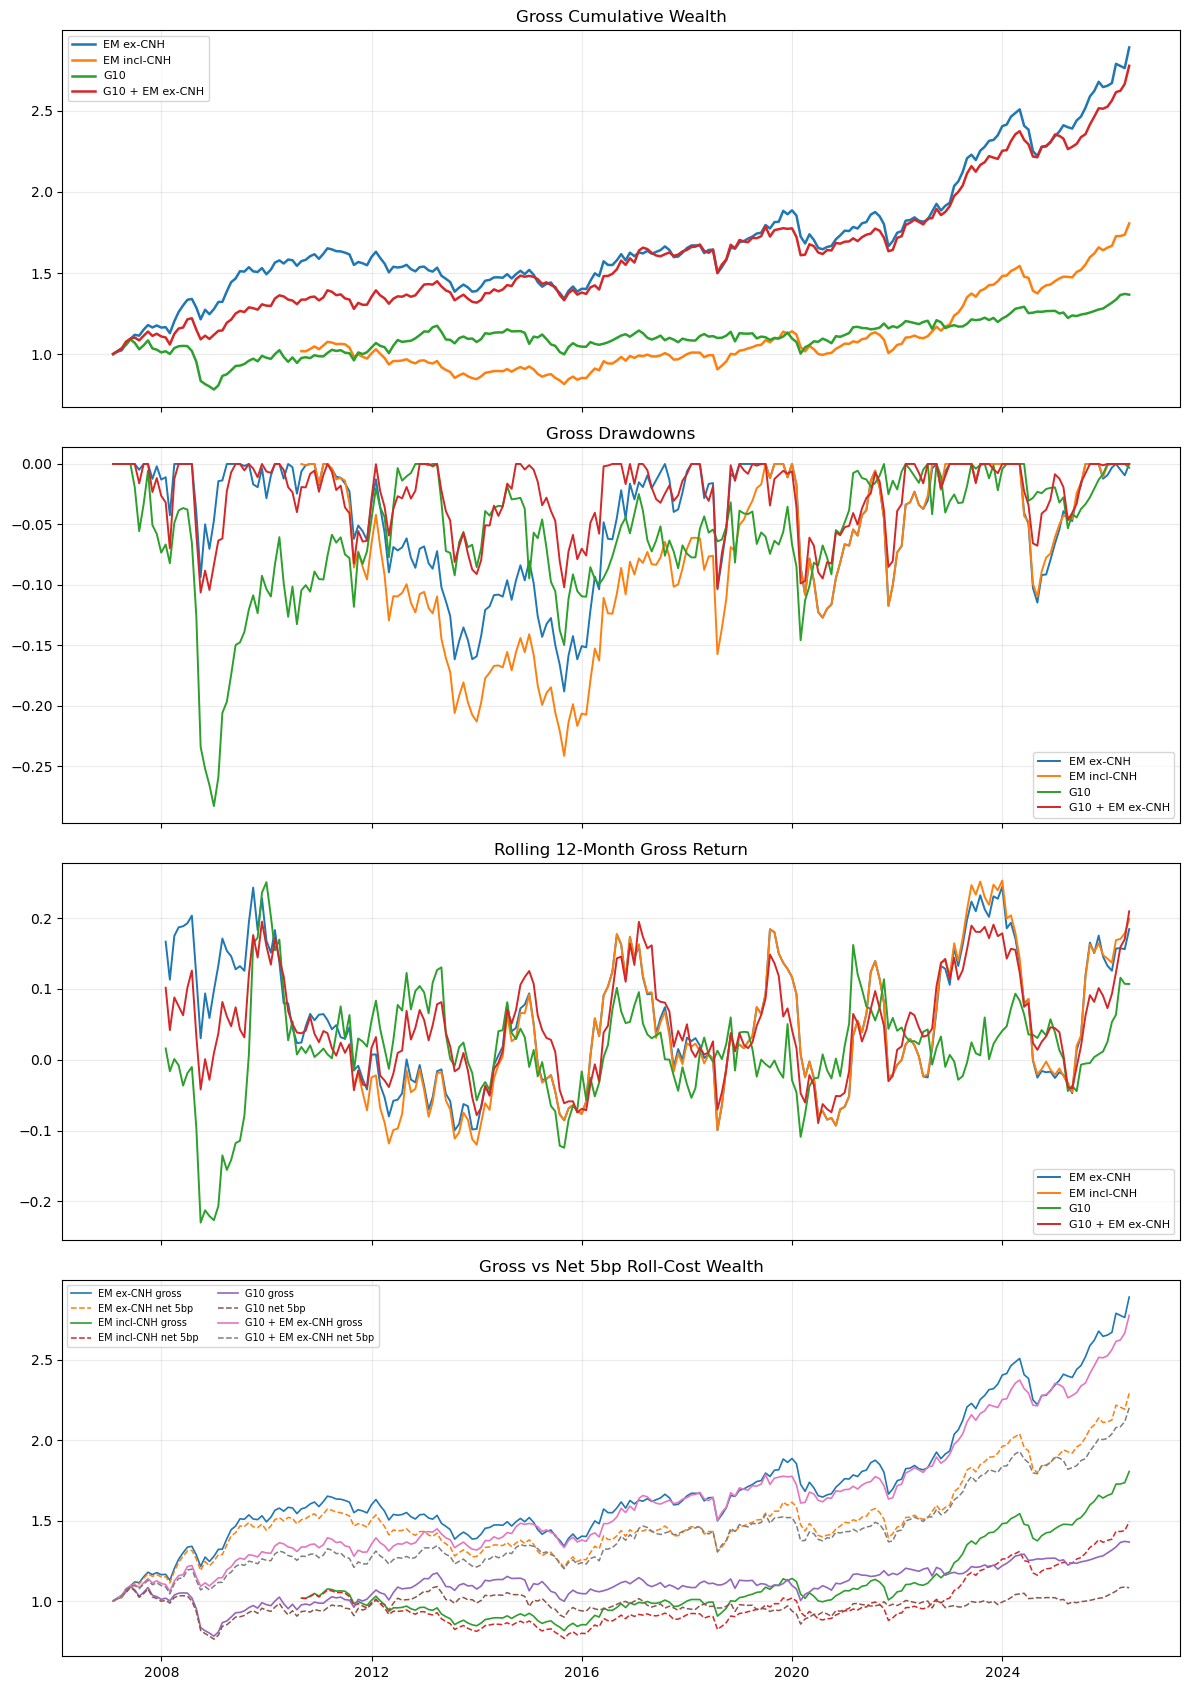

In [201]:
if plt is None or strategy_returns.empty:
    display(Markdown("Plots skipped because matplotlib is unavailable or no strategy returns were created."))
else:
    fig, axes = plt.subplots(4, 1, figsize=(12, 17), sharex=True)
    for strategy, sub in strategy_returns.groupby("strategy"):
        axes[0].plot(sub["month_end"], sub["wealth_gross"], label=strategy, linewidth=1.8)
        axes[1].plot(sub["month_end"], sub["drawdown_gross"], label=strategy, linewidth=1.4)
        axes[2].plot(sub["month_end"], sub["rolling_12m_gross_return"], label=strategy, linewidth=1.4)
    axes[0].set_title("Gross Cumulative Wealth")
    axes[1].set_title("Gross Drawdowns")
    axes[2].set_title("Rolling 12-Month Gross Return")
    for ax in axes[:3]:
        ax.grid(alpha=0.25); ax.legend(fontsize=8)
    # Cost comparison: 5bp for all plus 25bp for EM-oriented strategies.
    for strategy, sub in strategy_returns.groupby("strategy"):
        axes[3].plot(sub["month_end"], (1 + sub["gross_return"]).cumprod(), label=f"{strategy} gross", linewidth=1.2)
        axes[3].plot(sub["month_end"], (1 + sub["net_roll_5bp"]).cumprod(), label=f"{strategy} net 5bp", linewidth=1.1, linestyle="--")
    axes[3].set_title("Gross vs Net 5bp Roll-Cost Wealth")
    axes[3].grid(alpha=0.25); axes[3].legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()



---
# Basket Composition Diagnostics

The diagnostics below show whether each strategy is dominated by a small set of high-carry currencies. A concentration warning is triggered if TRY, BRL, ZAR, MXN, or HUF are selected very frequently in long baskets.


$$
\text{Turnover}_i = \sum_{t=1}^{T} \left| w_{i,t} - w_{i,t-1} \right|,\qquad w_{i,0} = 0
$$

In [202]:
def composition_diagnostics(weights):
    if weights.empty:
        return pd.DataFrame()
    w = weights.copy()
    w["is_long"] = w["basket"].eq("long_high_carry").astype(float)
    w["is_short"] = w["basket"].eq("short_low_carry").astype(float)
    # Recompute strategy/currency turnover from weights.
    rows=[]
    for strategy, sub in w.groupby("strategy"):
        wide=sub.pivot_table(index="month_end", columns="currency", values="weight", aggfunc="last").fillna(0.0).sort_index()
        turnover_by_ccy=(wide-wide.shift(1).fillna(0.0)).abs().sum()
        stats=(sub.groupby("currency").agg(long_selection_rate=("is_long","mean"), short_selection_rate=("is_short","mean"), average_weight=("weight","mean")).reset_index())
        stats["turnover"] = stats["currency"].map(turnover_by_ccy)
        stats["strategy"] = strategy
        rows.append(stats)
    return pd.concat(rows, ignore_index=True)

composition = composition_diagnostics(strategy_weights)
display(composition.sort_values(["strategy", "long_selection_rate"], ascending=[True, False]).style.format({"long_selection_rate": "{:.1%}", "short_selection_rate": "{:.1%}", "average_weight": "{:.3f}", "turnover": "{:.2f}"}) if not composition.empty else composition)

high_carry_watch = {"TRY", "BRL", "ZAR", "MXN", "HUF"}
concentration = composition[(composition["currency"].isin(high_carry_watch)) & (composition["long_selection_rate"] >= 0.40)].copy() if not composition.empty else pd.DataFrame()
if not concentration.empty:
    display(Markdown("### Concentration warning"))
    display(concentration[["strategy", "currency", "long_selection_rate", "average_weight", "turnover"]].sort_values(["strategy", "long_selection_rate"], ascending=[True, False]))


,currency,long_selection_rate,short_selection_rate,average_weight,turnover,strategy
15,TRY,93.6%,0.0%,0.234,4.25,EM ex-CNH
0,BRL,71.7%,0.0%,0.179,5.75,EM ex-CNH
16,ZAR,56.2%,0.0%,0.141,10.50,EM ex-CNH
8,MXN,43.3%,0.0%,0.108,4.00,EM ex-CNH
6,INR,42.9%,1.7%,0.103,15.75,EM ex-CNH
4,IDR,31.3%,0.0%,0.078,12.50,EM ex-CNH
2,COP,27.9%,10.7%,0.043,9.25,EM ex-CNH
3,HUF,13.0%,30.3%,-0.043,6.00,EM ex-CNH
11,PHP,7.1%,24.1%,-0.042,12.50,EM ex-CNH
1,CLP,6.0%,14.2%,-0.020,7.00,EM ex-CNH


### Concentration warning

,strategy,currency,long_selection_rate,average_weight,turnover
15,EM ex-CNH,TRY,0.935622,0.233906,4.250000
0,EM ex-CNH,BRL,0.716738,0.179185,5.750000
16,EM ex-CNH,ZAR,0.562232,0.140558,10.500000
8,EM ex-CNH,MXN,0.433476,0.108369,4.000000
33,EM incl-CNH,TRY,0.942105,0.235526,2.250000
17,EM incl-CNH,BRL,0.684211,0.171053,3.750000
26,EM incl-CNH,MXN,0.521053,0.130263,4.000000
34,EM incl-CNH,ZAR,0.515789,0.128947,8.500000
68,G10 + EM ex-CNH,TRY,1.000000,0.169957,0.566667
69,G10 + EM ex-CNH,ZAR,0.892704,0.152074,2.566667


In [203]:
CRISIS_WINDOWS = [
    {"period": "2008 global financial crisis", "start": "2008-07-31", "end": "2009-03-31"},
    {"period": "2013 taper tantrum", "start": "2013-05-31", "end": "2013-09-30"},
    {"period": "2015 EM / China stress", "start": "2015-06-30", "end": "2016-02-29"},
    {"period": "2020 Covid shock", "start": "2020-02-29", "end": "2020-04-30"},
    {"period": "2022 dollar / rates shock", "start": "2022-01-31", "end": "2022-10-31"},
]

rows=[]
for strategy, s0 in strategy_returns.groupby("strategy"):
    for win in CRISIS_WINDOWS:
        sub=s0[(s0["month_end"]>=pd.Timestamp(win["start"])) & (s0["month_end"]<=pd.Timestamp(win["end"]))].copy()
        r=sub["gross_return"].dropna()
        if r.empty:
            rows.append({"strategy": strategy, **win, "months": 0})
            continue
        worst=sub.loc[sub["gross_return"].idxmin()]
        rows.append({"strategy": strategy, **win, "months": len(r), "period_return": (1+r).prod()-1, "volatility": r.std(ddof=1)*np.sqrt(MONTHS_PER_YEAR) if len(r)>1 else np.nan, "max_drawdown": max_drawdown_initial(r), "worst_month": worst["month_end"].date().isoformat(), "worst_month_return": worst["gross_return"], "long_basket": worst["long_basket"], "short_basket": worst["short_basket"]})
crisis = pd.DataFrame(rows)
# display(crisis.style.format({"period_return": "{:.2%}", "volatility": "{:.2%}", "max_drawdown": "{:.2%}", "worst_month_return": "{:.2%}"}) if not crisis.empty else crisis)


# EM Carry Robustness and Attribution

This notebook tests whether the carry premium found in notebook 04 is broad-based or concentrated in a handful of high-carry currencies. The primary attribution candidate is **G10 + EM ex-CNH**, because notebook 04 identified the combined universe as the strongest risk-adjusted baseline. **EM ex-CNH** remains the key secondary comparison, since it isolates the EM carry premium and its concentration risk.


In [204]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    import matplotlib.colors as mcolors
except Exception:
    mcolors = None

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 220)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "theo" / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing theo/data/processed.")

ROOT = find_project_root()
PROCESSED_DIR = ROOT / "theo" / "data" / "processed"
EM_PANEL_PATH = PROCESSED_DIR / "em_1m_carry_panel.parquet"
G10_PANEL_PATH = PROCESSED_DIR / "g10_1m_carry_panel.parquet"
PREV_RETURNS_PATH = PROCESSED_DIR / "em_carry_strategy_returns.parquet"
PREV_COMPARISON_PATH = PROCESSED_DIR / "g10_em_carry_comparison.parquet"

STANDALONE_OUT = PROCESSED_DIR / "currency_standalone_performance.parquet"
CONTRIBUTIONS_OUT = PROCESSED_DIR / "currency_portfolio_contributions.parquet"
ROBUSTNESS_OUT = PROCESSED_DIR / "em_carry_robustness_results.parquet"
VARIANT_RETURNS_OUT = PROCESSED_DIR / "em_carry_robustness_strategy_returns.parquet"

MONTHS_PER_YEAR = 12
ROLL_COST_BPS = [2, 5, 10, 25, 50]
VOL_TARGETS = [0.08, 0.10]
MAX_LEVERAGE = 2.0
HIGH_CARRY_WATCH = ["TRY", "BRL", "ZAR", "MXN", "INR", "HUF"]

# Attribution view configuration. The combined strategy is the primary candidate
# from notebook 04; EM ex-CNH remains the secondary EM-only lens.
PRIMARY_ATTRIBUTION_STRATEGY = "G10 + EM ex-CNH"
SECONDARY_ATTRIBUTION_STRATEGIES = ["EM ex-CNH"]
ATTRIBUTION_STRATEGIES_TO_PLOT = [
    PRIMARY_ATTRIBUTION_STRATEGY,
    *SECONDARY_ATTRIBUTION_STRATEGIES,
]


# print(f"Project root: {ROOT}")
# print(f"Processed folder: {PROCESSED_DIR}")


In [205]:
def safe_read_parquet(path, required=False):
    if not path.exists():
        msg = f"Missing file: {path.relative_to(ROOT) if path.is_relative_to(ROOT) else path}"
        if required:
            warnings.warn(msg + "; downstream sections may be empty unless reconstructable.")
        return pd.DataFrame(), {"path": str(path), "loaded": False, "rows": 0, "message": msg}
    try:
        df = pd.read_parquet(path)
        return df, {"path": str(path.relative_to(ROOT)), "loaded": True, "rows": len(df), "message": ""}
    except Exception as exc:
        warnings.warn(f"Could not read {path}: {repr(exc)}")
        return pd.DataFrame(), {"path": str(path), "loaded": False, "rows": 0, "message": repr(exc)}

em_raw_panel, st_em = safe_read_parquet(EM_PANEL_PATH, required=True)
g10_raw_panel, st_g10 = safe_read_parquet(G10_PANEL_PATH, required=True)
prev_returns, st_prev_ret = safe_read_parquet(PREV_RETURNS_PATH, required=False)
prev_comparison, st_prev_comp = safe_read_parquet(PREV_COMPARISON_PATH, required=False)

# display(pd.DataFrame([st_em, st_g10, st_prev_ret, st_prev_comp]))


In [206]:
def harmonize_em_panel(df):
    if df.empty:
        return pd.DataFrame(columns=["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return", "data_quality_flag"])
    out = df.copy()
    out["month_end"] = pd.to_datetime(out["month_end"], errors="coerce")
    out["asset_class"] = "EM"
    out["data_quality_flag"] = out.get("data_quality_flag", "ok")
    return out[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return", "data_quality_flag"]].copy()


def harmonize_g10_panel(df):
    if df.empty:
        return pd.DataFrame(columns=["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return", "data_quality_flag"])
    out = df.copy()
    out["month_end"] = pd.to_datetime(out["month_end"], errors="coerce")
    out["asset_class"] = "G10"
    # Recompute log carry/return for consistency with EM notebook 04 when possible.
    if {"spot_usd_per_ccy", "forward_1m_usd_per_ccy", "next_month_spot_usd_per_ccy"}.issubset(out.columns):
        out["carry_signal_1m"] = np.log(out["spot_usd_per_ccy"]) - np.log(out["forward_1m_usd_per_ccy"])
        out["realized_1m_forward_excess_return"] = np.log(out["next_month_spot_usd_per_ccy"]) - np.log(out["forward_1m_usd_per_ccy"])
    out["data_quality_flag"] = "ok"
    return out[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return", "data_quality_flag"]].copy()

em_panel = harmonize_em_panel(em_raw_panel)
g10_panel = harmonize_g10_panel(g10_raw_panel)
combined_panel = pd.concat([g10_panel, em_panel], ignore_index=True).sort_values(["asset_class", "currency", "month_end"])

load_summary = combined_panel.groupby("asset_class").agg(rows=("currency", "size"), currencies=("currency", "nunique"), first=("month_end", "min"), last=("month_end", "max")).reset_index()
display(load_summary)


,asset_class,rows,currencies,first,last
0,EM,4169,18,2007-01-31,2026-06-30
1,G10,2106,9,2007-01-31,2026-06-30


In [207]:
def max_drawdown_initial(return_series):
    r = return_series.dropna().astype(float)
    if r.empty:
        return np.nan
    wealth = pd.concat([pd.Series([1.0], index=["initial"]), (1.0 + r).cumprod()])
    return (wealth / wealth.cummax() - 1.0).min()


def perf_stats(return_series, months_per_year=MONTHS_PER_YEAR):
    r = return_series.dropna().astype(float)
    if r.empty:
        return {"months": 0, "annualized_return": np.nan, "annualized_volatility": np.nan, "sharpe_ratio": np.nan, "max_drawdown": np.nan, "skewness": np.nan, "hit_rate": np.nan, "worst_month": np.nan, "best_month": np.nan, "final_cumulative_return": np.nan}
    ann = (1.0 + r).prod() ** (months_per_year / len(r)) - 1.0
    vol = r.std(ddof=1) * np.sqrt(months_per_year)
    return {"months": len(r), "annualized_return": ann, "annualized_volatility": vol, "sharpe_ratio": ann / vol if vol and pd.notna(vol) else np.nan, "max_drawdown": max_drawdown_initial(r), "skewness": r.skew(), "hit_rate": (r > 0).mean(), "worst_month": r.min(), "best_month": r.max(), "final_cumulative_return": (1.0 + r).prod() - 1.0}


def choose_leg_size(n):
    if n < 2:
        return 0
    if n >= 6:
        return min(max(math.ceil(0.20 * n), 3), n // 2)
    return max(1, n // 3)


def assign_weights(month_df, weight_cap=None):
    sub = month_df.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"]).copy()
    sub = sub.sort_values(["carry_signal_1m", "currency"], ascending=[True, True])
    n = len(sub)
    sub["weight"] = 0.0
    sub["basket"] = "middle"
    if n < 2:
        return sub.iloc[0:0]
    if weight_cap is None:
        k = choose_leg_size(n)
    else:
        k = max(choose_leg_size(n), math.ceil(1.0 / weight_cap))
        k = min(k, n // 2)
    if k == 0 or n < 2 * k:
        return sub.iloc[0:0]
    short_idx = sub.head(k).index
    long_idx = sub.tail(k).index
    long_weight = 1.0 / k
    short_weight = -1.0 / k
    if weight_cap is not None:
        long_weight = min(long_weight, weight_cap)
        short_weight = -min(abs(short_weight), weight_cap)
        # With k >= ceil(1/cap), equal weights should satisfy the cap and sum to one.
        long_weight = 1.0 / k
        short_weight = -1.0 / k
    sub.loc[short_idx, "weight"] = short_weight
    sub.loc[short_idx, "basket"] = "short_low_carry"
    sub.loc[long_idx, "weight"] = long_weight
    sub.loc[long_idx, "basket"] = "long_high_carry"
    sub["leg_size"] = k
    sub["n_universe"] = n
    return sub


def build_strategy(panel, strategy_name, exclude=None, weight_cap=None, min_start=None):
    exclude = set(exclude or [])
    df = panel.copy()
    if exclude:
        df = df[~df["currency"].isin(exclude)].copy()
    if min_start is not None:
        df = df[df["month_end"] >= pd.Timestamp(min_start)].copy()
    pieces = []
    for month_end, sub in df.groupby("month_end", sort=True):
        assigned = assign_weights(sub, weight_cap=weight_cap)
        if assigned.empty:
            continue
        assigned["month_end"] = month_end
        assigned["strategy"] = strategy_name
        assigned["excluded_currencies"] = ", ".join(sorted(exclude))
        assigned["weight_cap"] = weight_cap if weight_cap is not None else np.nan
        pieces.append(assigned)
    if not pieces:
        return pd.DataFrame(), pd.DataFrame()
    weights = pd.concat(pieces, ignore_index=True).sort_values(["strategy", "month_end", "currency"])
    weights["contribution"] = weights["weight"] * weights["realized_1m_forward_excess_return"]

    wide = weights.pivot_table(index="month_end", columns="currency", values="weight", aggfunc="last").fillna(0.0).sort_index()
    turnover = (wide - wide.shift(1).fillna(0.0)).abs().sum(axis=1).rename("rebalancing_turnover")
    hhi = (wide.pow(2).sum(axis=1)).rename("hhi_weights")
    neff = (1.0 / hhi.replace(0, np.nan)).rename("effective_n_currencies")

    rows = []
    for month_end, sub in weights.groupby("month_end", sort=True):
        rows.append({"strategy": strategy_name, "month_end": month_end, "gross_return": sub["contribution"].sum(), "gross_roll_notional": sub["weight"].abs().sum(), "rebalancing_turnover": turnover.loc[month_end], "hhi_weights": hhi.loc[month_end], "effective_n_currencies": neff.loc[month_end], "n_universe": sub["n_universe"].max(), "leg_size": sub["leg_size"].max(), "long_basket": ", ".join(sorted(sub.loc[sub["basket"].eq("long_high_carry"), "currency"])), "short_basket": ", ".join(sorted(sub.loc[sub["basket"].eq("short_low_carry"), "currency"])), "excluded_currencies": ", ".join(sorted(exclude)), "weight_cap": weight_cap if weight_cap is not None else np.nan})
    returns = pd.DataFrame(rows).sort_values("month_end")
    for bps in ROLL_COST_BPS:
        returns[f"net_roll_{bps}bp"] = returns["gross_return"] - returns["gross_roll_notional"] * bps / 10000.0
    returns["wealth_gross"] = (1.0 + returns["gross_return"]).cumprod()
    returns["drawdown_gross"] = returns["wealth_gross"] / returns["wealth_gross"].cummax() - 1.0
    returns["rolling_12m_return"] = returns["wealth_gross"] / returns["wealth_gross"].shift(12) - 1.0
    return weights, returns


def performance_table_for_returns(returns, label_cols=None, scenarios=("gross_return",)):
    label_cols = label_cols or []
    rows = []
    if returns.empty:
        return pd.DataFrame()
    group_cols = ["strategy"] + label_cols
    for keys, sub in returns.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        label = dict(zip(group_cols, keys))
        scenario_cols = ["gross_return"] + [f"net_roll_{bps}bp" for bps in ROLL_COST_BPS if f"net_roll_{bps}bp" in sub.columns]
        for col in scenario_cols:
            stats = perf_stats(sub[col])
            row = {**label, "scenario": "Gross" if col == "gross_return" else col.replace("net_roll_", "Net roll ").replace("bp", "bp"), **stats, "avg_n_universe": sub["n_universe"].mean() if "n_universe" in sub else np.nan, "avg_gross_roll_notional": sub["gross_roll_notional"].mean() if "gross_roll_notional" in sub else np.nan, "avg_rebalancing_turnover": sub["rebalancing_turnover"].mean() if "rebalancing_turnover" in sub else np.nan, "avg_effective_n": sub["effective_n_currencies"].mean() if "effective_n_currencies" in sub else np.nan}
            rows.append(row)
    return pd.DataFrame(rows)


In [208]:
EM_EX_CNH = sorted([c for c in em_panel["currency"].dropna().unique() if c != "CNH"])
CNH_FIRST = em_panel.loc[(em_panel["currency"].eq("CNH")) & em_panel["realized_1m_forward_excess_return"].notna(), "month_end"].min()

sample_panels = {
    "G10": g10_panel.copy(),
    "EM ex-CNH": em_panel[em_panel["currency"].isin(EM_EX_CNH)].copy(),
    "EM incl-CNH": em_panel[em_panel["month_end"] >= CNH_FIRST].copy() if pd.notna(CNH_FIRST) else em_panel.iloc[0:0].copy(),
    "G10 + EM ex-CNH": pd.concat([g10_panel, em_panel[em_panel["currency"].isin(EM_EX_CNH)]], ignore_index=True),
}

baseline_weights_list = []
baseline_returns_list = []
for name, df in sample_panels.items():
    w, r = build_strategy(df, name)
    baseline_weights_list.append(w)
    baseline_returns_list.append(r)
baseline_weights = pd.concat([x for x in baseline_weights_list if not x.empty], ignore_index=True)
baseline_returns = pd.concat([x for x in baseline_returns_list if not x.empty], ignore_index=True)
baseline_performance = performance_table_for_returns(baseline_returns)

display(baseline_returns.groupby("strategy").agg(months=("month_end", "count"), first=("month_end", "min"), last=("month_end", "max"), avg_n=("n_universe", "mean"), avg_eff_n=("effective_n_currencies", "mean")))
display(baseline_performance[baseline_performance["scenario"].isin(["Gross", "Net roll 5bp", "Net roll 25bp"])].style.format({"annualized_return":"{:.2%}", "annualized_volatility":"{:.2%}", "sharpe_ratio":"{:.2f}", "max_drawdown":"{:.2%}", "skewness":"{:.2f}", "hit_rate":"{:.2%}", "final_cumulative_return":"{:.2%}", "avg_n_universe":"{:.1f}", "avg_effective_n":"{:.2f}"}))


,months,first,last,avg_n,avg_eff_n
strategy,,,,,
EM ex-CNH,233,2007-01-31,2026-05-31,16.901288,2.000000
EM incl-CNH,190,2010-08-31,2026-05-31,17.889474,2.000000
G10,233,2007-01-31,2026-05-31,9.000000,1.500000
G10 + EM ex-CNH,233,2007-01-31,2026-05-31,25.901288,2.950644


,strategy,scenario,months,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,skewness,hit_rate,worst_month,best_month,final_cumulative_return,avg_n_universe,avg_gross_roll_notional,avg_rebalancing_turnover,avg_effective_n
0,EM ex-CNH,Gross,233,5.62%,7.90%,0.71,-18.83%,-0.62,62.23%,-0.088123,0.064945,189.04%,16.9,2.000000,0.671674,2.00
2,EM ex-CNH,Net roll 5bp,233,4.36%,7.90%,0.55,-23.11%,-0.62,60.09%,-0.089123,0.063945,129.17%,16.9,2.000000,0.671674,2.00
4,EM ex-CNH,Net roll 25bp,233,-0.52%,7.90%,-0.07,-47.85%,-0.62,53.22%,-0.093123,0.059945,-9.65%,16.9,2.000000,0.671674,2.00
6,EM incl-CNH,Gross,190,3.80%,7.73%,0.49,-24.16%,-0.87,61.58%,-0.088123,0.061864,80.59%,17.9,2.000000,0.650000,2.00
8,EM incl-CNH,Net roll 5bp,190,2.57%,7.73%,0.33,-28.17%,-0.87,59.47%,-0.089123,0.060864,49.40%,17.9,2.000000,0.650000,2.00
10,EM incl-CNH,Net roll 25bp,190,-2.24%,7.73%,-0.29,-50.75%,-0.87,52.11%,-0.093123,0.056864,-30.14%,17.9,2.000000,0.650000,2.00
12,G10,Gross,233,1.62%,7.85%,0.21,-28.31%,-0.92,57.08%,-0.123562,0.072124,36.71%,9.0,2.000000,0.246066,1.50
14,G10,Net roll 5bp,233,0.41%,7.85%,0.05,-29.69%,-0.92,54.51%,-0.124562,0.071124,8.31%,9.0,2.000000,0.246066,1.50
16,G10,Net roll 25bp,233,-4.30%,7.85%,-0.55,-61.65%,-0.92,44.64%,-0.128562,0.067124,-57.43%,9.0,2.000000,0.246066,1.50
18,G10 + EM ex-CNH,Gross,233,5.40%,7.41%,0.73,-10.64%,-0.49,60.09%,-0.086685,0.061879,177.71%,25.9,2.000000,0.460372,2.95


In [209]:
available_attribution_strategies = set(baseline_returns["strategy"].dropna().unique()) if not baseline_returns.empty else set()
VALID_ATTRIBUTION_STRATEGIES_TO_PLOT = []
for strategy in ATTRIBUTION_STRATEGIES_TO_PLOT:
    if strategy in available_attribution_strategies and strategy not in VALID_ATTRIBUTION_STRATEGIES_TO_PLOT:
        VALID_ATTRIBUTION_STRATEGIES_TO_PLOT.append(strategy)
    else:
        warnings.warn(f"Attribution strategy unavailable or duplicated and will be skipped: {strategy}")

if not VALID_ATTRIBUTION_STRATEGIES_TO_PLOT and available_attribution_strategies:
    fallback_strategy = sorted(available_attribution_strategies)[0]
    warnings.warn(f"No requested attribution strategy is available. Falling back to {fallback_strategy}.")
    VALID_ATTRIBUTION_STRATEGIES_TO_PLOT = [fallback_strategy]

strategy_config_summary = pd.DataFrame({
    "role": ["primary"] + ["secondary"] * max(0, len(VALID_ATTRIBUTION_STRATEGIES_TO_PLOT) - 1),
    "strategy": VALID_ATTRIBUTION_STRATEGIES_TO_PLOT,
})
# display(strategy_config_summary)


In [210]:
def standalone_performance(panel):
    rows = []
    for (asset_class, ccy), sub in panel.dropna(subset=["realized_1m_forward_excess_return"]).groupby(["asset_class", "currency"]):
        r = sub.sort_values("month_end")["realized_1m_forward_excess_return"]
        stats = perf_stats(r)
        rows.append({"asset_class": asset_class, "currency": ccy, **stats, "average_carry_signal": sub["carry_signal_1m"].mean(), "valid_months": len(r), "first_available_date": sub["month_end"].min(), "last_available_date": sub["month_end"].max()})
    return pd.DataFrame(rows).sort_values("annualized_return", ascending=False)

standalone_perf = standalone_performance(combined_panel)
display(standalone_perf.style.format({"annualized_return":"{:.2%}", "annualized_volatility":"{:.2%}", "sharpe_ratio":"{:.2f}", "max_drawdown":"{:.2%}", "skewness":"{:.2f}", "hit_rate":"{:.2%}", "worst_month":"{:.2%}", "best_month":"{:.2%}", "final_cumulative_return":"{:.2%}", "average_carry_signal":"{:.3%}"}))


,asset_class,currency,months,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,skewness,hit_rate,worst_month,best_month,final_cumulative_return,average_carry_signal,valid_months,first_available_date,last_available_date
11,EM,PEN,233,1.61%,6.07%,0.27,-20.21%,0.21,54.94%,-5.37%,6.58%,36.35%,0.176%,233,2007-01-31 00:00:00,2026-05-31 00:00:00
9,EM,MXN,233,1.56%,12.05%,0.13,-37.56%,-1.26,57.94%,-18.17%,9.15%,35.17%,0.390%,233,2007-01-31 00:00:00,2026-05-31 00:00:00
0,EM,BRL,233,1.35%,15.46%,0.09,-53.98%,-0.45,53.65%,-16.21%,12.62%,29.64%,0.593%,233,2007-01-31 00:00:00,2026-05-31 00:00:00
6,EM,ILS,233,1.07%,8.69%,0.12,-27.57%,-0.24,51.07%,-7.35%,7.86%,23.04%,-0.034%,233,2007-01-31 00:00:00,2026-05-31 00:00:00
12,EM,PHP,212,1.03%,6.26%,0.16,-15.51%,-0.29,58.02%,-5.10%,4.03%,19.86%,0.178%,212,2007-01-31 00:00:00,2026-05-31 00:00:00
15,EM,THB,233,1.01%,7.03%,0.14,-24.22%,-0.32,58.37%,-7.00%,7.43%,21.61%,0.072%,233,2007-01-31 00:00:00,2026-05-31 00:00:00
3,EM,COP,233,0.93%,14.20%,0.07,-55.08%,-0.25,51.93%,-13.78%,11.07%,19.72%,0.340%,233,2007-01-31 00:00:00,2026-05-31 00:00:00
2,EM,CNH,190,0.86%,4.56%,0.19,-18.66%,-0.48,60.00%,-4.20%,3.87%,14.50%,0.082%,190,2010-08-31 00:00:00,2026-05-31 00:00:00
7,EM,INR,233,0.78%,7.45%,0.11,-22.73%,-0.05,53.22%,-7.52%,8.03%,16.34%,0.415%,233,2007-01-31 00:00:00,2026-05-31 00:00:00
5,EM,IDR,233,0.37%,9.44%,0.04,-27.95%,-0.45,52.36%,-14.63%,12.30%,7.45%,0.358%,233,2007-01-31 00:00:00,2026-05-31 00:00:00


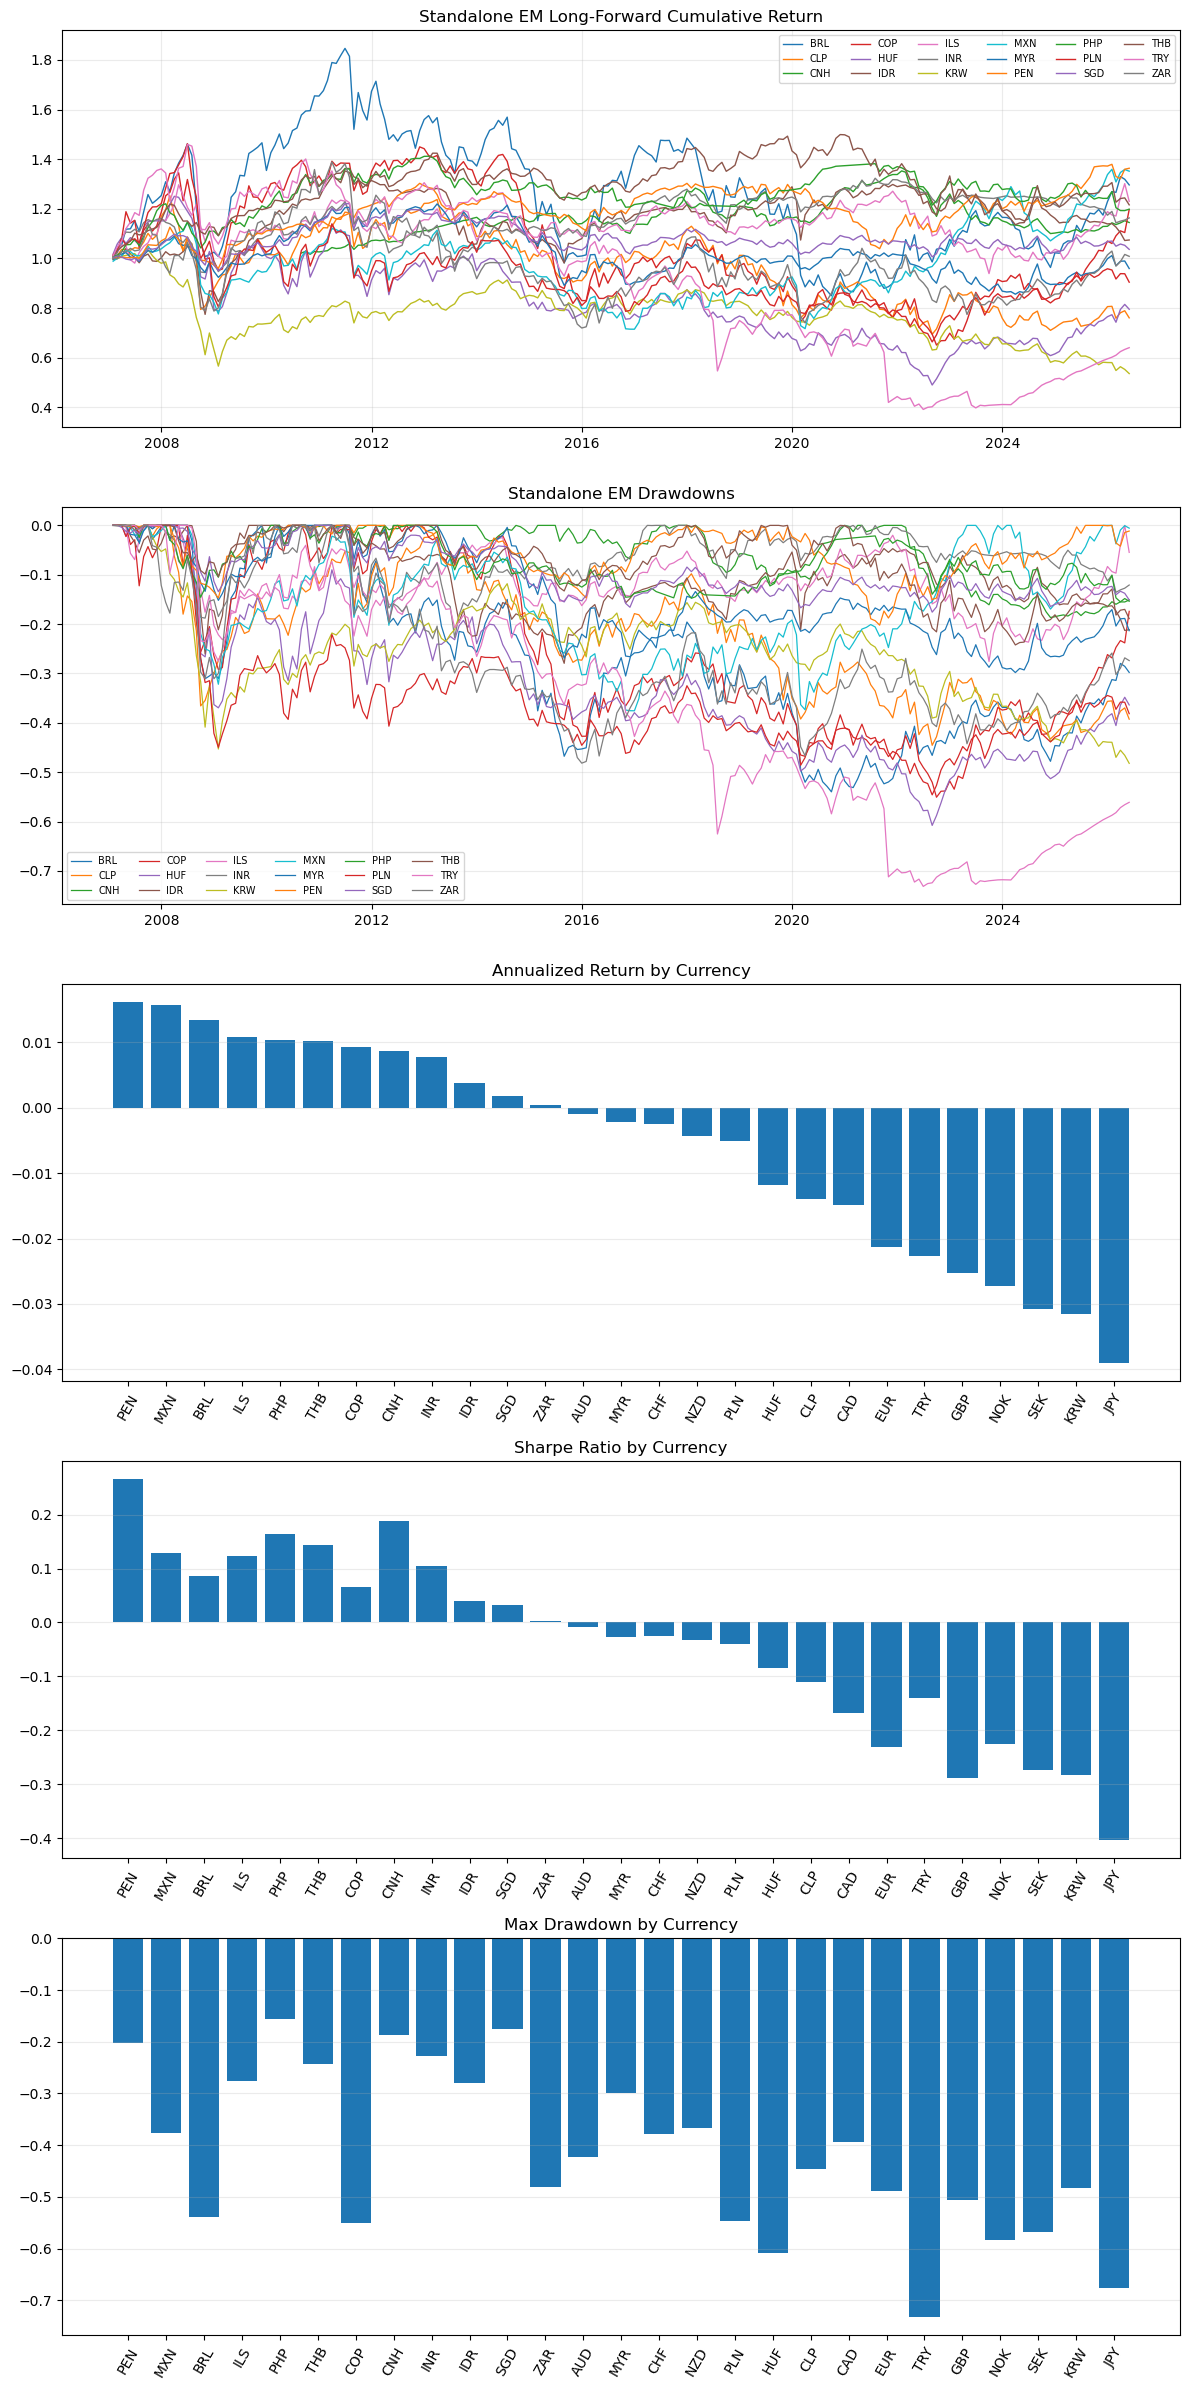

In [211]:
if plt is None or standalone_perf.empty:
    display(Markdown("Standalone plots skipped because matplotlib is unavailable or data are empty."))
else:
    standalone_panel = combined_panel.dropna(subset=["realized_1m_forward_excess_return"]).copy()
    standalone_panel["wealth"] = standalone_panel.groupby(["asset_class", "currency"])["realized_1m_forward_excess_return"].transform(lambda x: (1+x).cumprod())
    standalone_panel["drawdown"] = standalone_panel.groupby(["asset_class", "currency"])["wealth"].transform(lambda x: x / x.cummax() - 1)

    fig, axes = plt.subplots(5, 1, figsize=(12, 24))
    for ccy, sub in standalone_panel[standalone_panel["asset_class"].eq("EM")].groupby("currency"):
        axes[0].plot(sub["month_end"], sub["wealth"], label=ccy, linewidth=1.0)
        axes[1].plot(sub["month_end"], sub["drawdown"], label=ccy, linewidth=0.9)
    axes[0].set_title("Standalone EM Long-Forward Cumulative Return")
    axes[1].set_title("Standalone EM Drawdowns")
    axes[0].legend(ncol=6, fontsize=7)
    axes[1].legend(ncol=6, fontsize=7)
    for ax in axes[:2]: ax.grid(alpha=0.25)

    top = standalone_perf.sort_values("annualized_return", ascending=False)
    axes[2].bar(top["currency"], top["annualized_return"])
    axes[2].set_title("Annualized Return by Currency")
    axes[2].tick_params(axis='x', rotation=60)
    axes[3].bar(top["currency"], top["sharpe_ratio"])
    axes[3].set_title("Sharpe Ratio by Currency")
    axes[3].tick_params(axis='x', rotation=60)
    axes[4].bar(top["currency"], top["max_drawdown"])
    axes[4].set_title("Max Drawdown by Currency")
    axes[4].tick_params(axis='x', rotation=60)
    for ax in axes[2:]: ax.grid(axis="y", alpha=0.25)
    plt.tight_layout(); plt.show()


In [212]:
if standalone_perf.empty:
    display(Markdown("No standalone interpretation available."))
else:
    top5 = standalone_perf.head(5)["currency"].tolist()
    risky = standalone_perf[standalone_perf["currency"].isin(HIGH_CARRY_WATCH)].sort_values("annualized_return", ascending=False)[["currency", "annualized_return", "max_drawdown", "skewness", "sharpe_ratio"]]
    # display(Markdown(f"Strongest standalone currencies by annualized return: **{', '.join(top5)}**."))
    # display(risky.style.format({"annualized_return":"{:.2%}", "max_drawdown":"{:.2%}", "skewness":"{:.2f}", "sharpe_ratio":"{:.2f}"}))


In [213]:
CRISIS_WINDOWS = [
    {"period": "2008 global financial crisis", "start": "2008-07-31", "end": "2009-03-31"},
    {"period": "2013 taper tantrum", "start": "2013-05-31", "end": "2013-09-30"},
    {"period": "2015 EM / China stress", "start": "2015-06-30", "end": "2016-02-29"},
    {"period": "2020 Covid shock", "start": "2020-02-29", "end": "2020-04-30"},
    {"period": "2022 dollar / rates shock", "start": "2022-01-31", "end": "2022-10-31"},
]

def first_valid(series, default="Unknown"):
    vals = series.dropna().astype(str)
    return vals.iloc[0] if len(vals) else default

def add_portfolio_month_flags(weights, returns):
    ret_flags = returns[["strategy", "month_end", "gross_return"]].copy()
    weights = weights.merge(ret_flags, on=["strategy", "month_end"], how="left", suffixes=("", "_portfolio"))
    weights["positive_portfolio_month"] = weights["gross_return"].gt(0)
    weights["negative_portfolio_month"] = weights["gross_return"].lt(0)
    weights["worst10_month"] = False
    for strategy, sub in returns.groupby("strategy"):
        worst_months = set(sub.sort_values("gross_return").head(10)["month_end"])
        weights.loc[weights["strategy"].eq(strategy) & weights["month_end"].isin(worst_months), "worst10_month"] = True
    weights["crisis_period"] = ""
    for win in CRISIS_WINDOWS:
        mask = (weights["month_end"] >= pd.Timestamp(win["start"])) & (weights["month_end"] <= pd.Timestamp(win["end"]))
        weights.loc[mask, "crisis_period"] = win["period"]
    return weights

contribution_panel = add_portfolio_month_flags(baseline_weights.copy(), baseline_returns.copy())

if "asset_class" not in contribution_panel.columns:
    contribution_panel["asset_class"] = np.where(contribution_panel["currency"].isin(G10_CURRENCIES), "G10", "EM")

def aggregate_contributions(cp):
    rows=[]
    for (strategy, ccy), sub in cp.groupby(["strategy", "currency"]):
        rows.append({
            "strategy": strategy,
            "asset_class": first_valid(sub["asset_class"]),
            "currency": ccy,
            "total_cumulative_contribution": sub["contribution"].sum(),
            "average_monthly_contribution": sub["contribution"].mean(),
            "annualized_contribution": sub["contribution"].mean() * MONTHS_PER_YEAR,
            "contribution_positive_months": sub.loc[sub["positive_portfolio_month"], "contribution"].sum(),
            "contribution_negative_months": sub.loc[sub["negative_portfolio_month"], "contribution"].sum(),
            "contribution_worst10_months": sub.loc[sub["worst10_month"], "contribution"].sum(),
            "long_side_contribution": sub.loc[sub["basket"].eq("long_high_carry"), "contribution"].sum(),
            "short_side_contribution": sub.loc[sub["basket"].eq("short_low_carry"), "contribution"].sum(),
        })
    out = pd.DataFrame(rows)
    crisis_rows=[]
    crisis = cp[cp["crisis_period"].ne("")]
    if not crisis.empty:
        for (strategy, ccy, period), sub in crisis.groupby(["strategy", "currency", "crisis_period"]):
            crisis_rows.append({
                "strategy": strategy,
                "asset_class": first_valid(sub["asset_class"]),
                "currency": ccy,
                "crisis_period": period,
                "crisis_contribution": sub["contribution"].sum(),
            })
    crisis_out = pd.DataFrame(crisis_rows)
    return out.sort_values(["strategy", "total_cumulative_contribution"], ascending=[True, False]), crisis_out

contribution_summary, crisis_contrib_long = aggregate_contributions(contribution_panel)
display(contribution_summary.style.format({c:"{:.2%}" for c in contribution_summary.select_dtypes(include=[float]).columns}) if not contribution_summary.empty else contribution_summary)


,strategy,asset_class,currency,total_cumulative_contribution,average_monthly_contribution,annualized_contribution,contribution_positive_months,contribution_negative_months,contribution_worst10_months,long_side_contribution,short_side_contribution
0,EM ex-CNH,EM,BRL,20.32%,0.09%,1.05%,57.83%,-37.52%,-14.05%,20.32%,0.00%
2,EM ex-CNH,EM,COP,20.18%,0.09%,1.04%,18.16%,2.02%,-0.24%,17.95%,2.23%
7,EM ex-CNH,EM,KRW,18.79%,0.08%,0.97%,18.63%,0.16%,3.77%,0.00%,18.79%
3,EM ex-CNH,EM,HUF,18.75%,0.08%,0.97%,16.72%,2.03%,-0.49%,9.72%,9.03%
4,EM ex-CNH,EM,IDR,13.42%,0.06%,0.69%,14.03%,-0.61%,-2.80%,13.42%,0.00%
8,EM ex-CNH,EM,MXN,10.65%,0.05%,0.55%,19.28%,-8.63%,-8.98%,10.65%,0.00%
6,EM ex-CNH,EM,INR,10.10%,0.04%,0.52%,19.18%,-9.07%,-6.17%,11.47%,-1.37%
11,EM ex-CNH,EM,PHP,8.18%,0.04%,0.46%,0.69%,7.50%,2.42%,4.63%,3.56%
14,EM ex-CNH,EM,THB,4.55%,0.02%,0.23%,7.83%,-3.29%,-1.23%,2.66%,1.88%
10,EM ex-CNH,EM,PEN,4.20%,0.02%,0.22%,5.40%,-1.20%,0.96%,-0.07%,4.27%


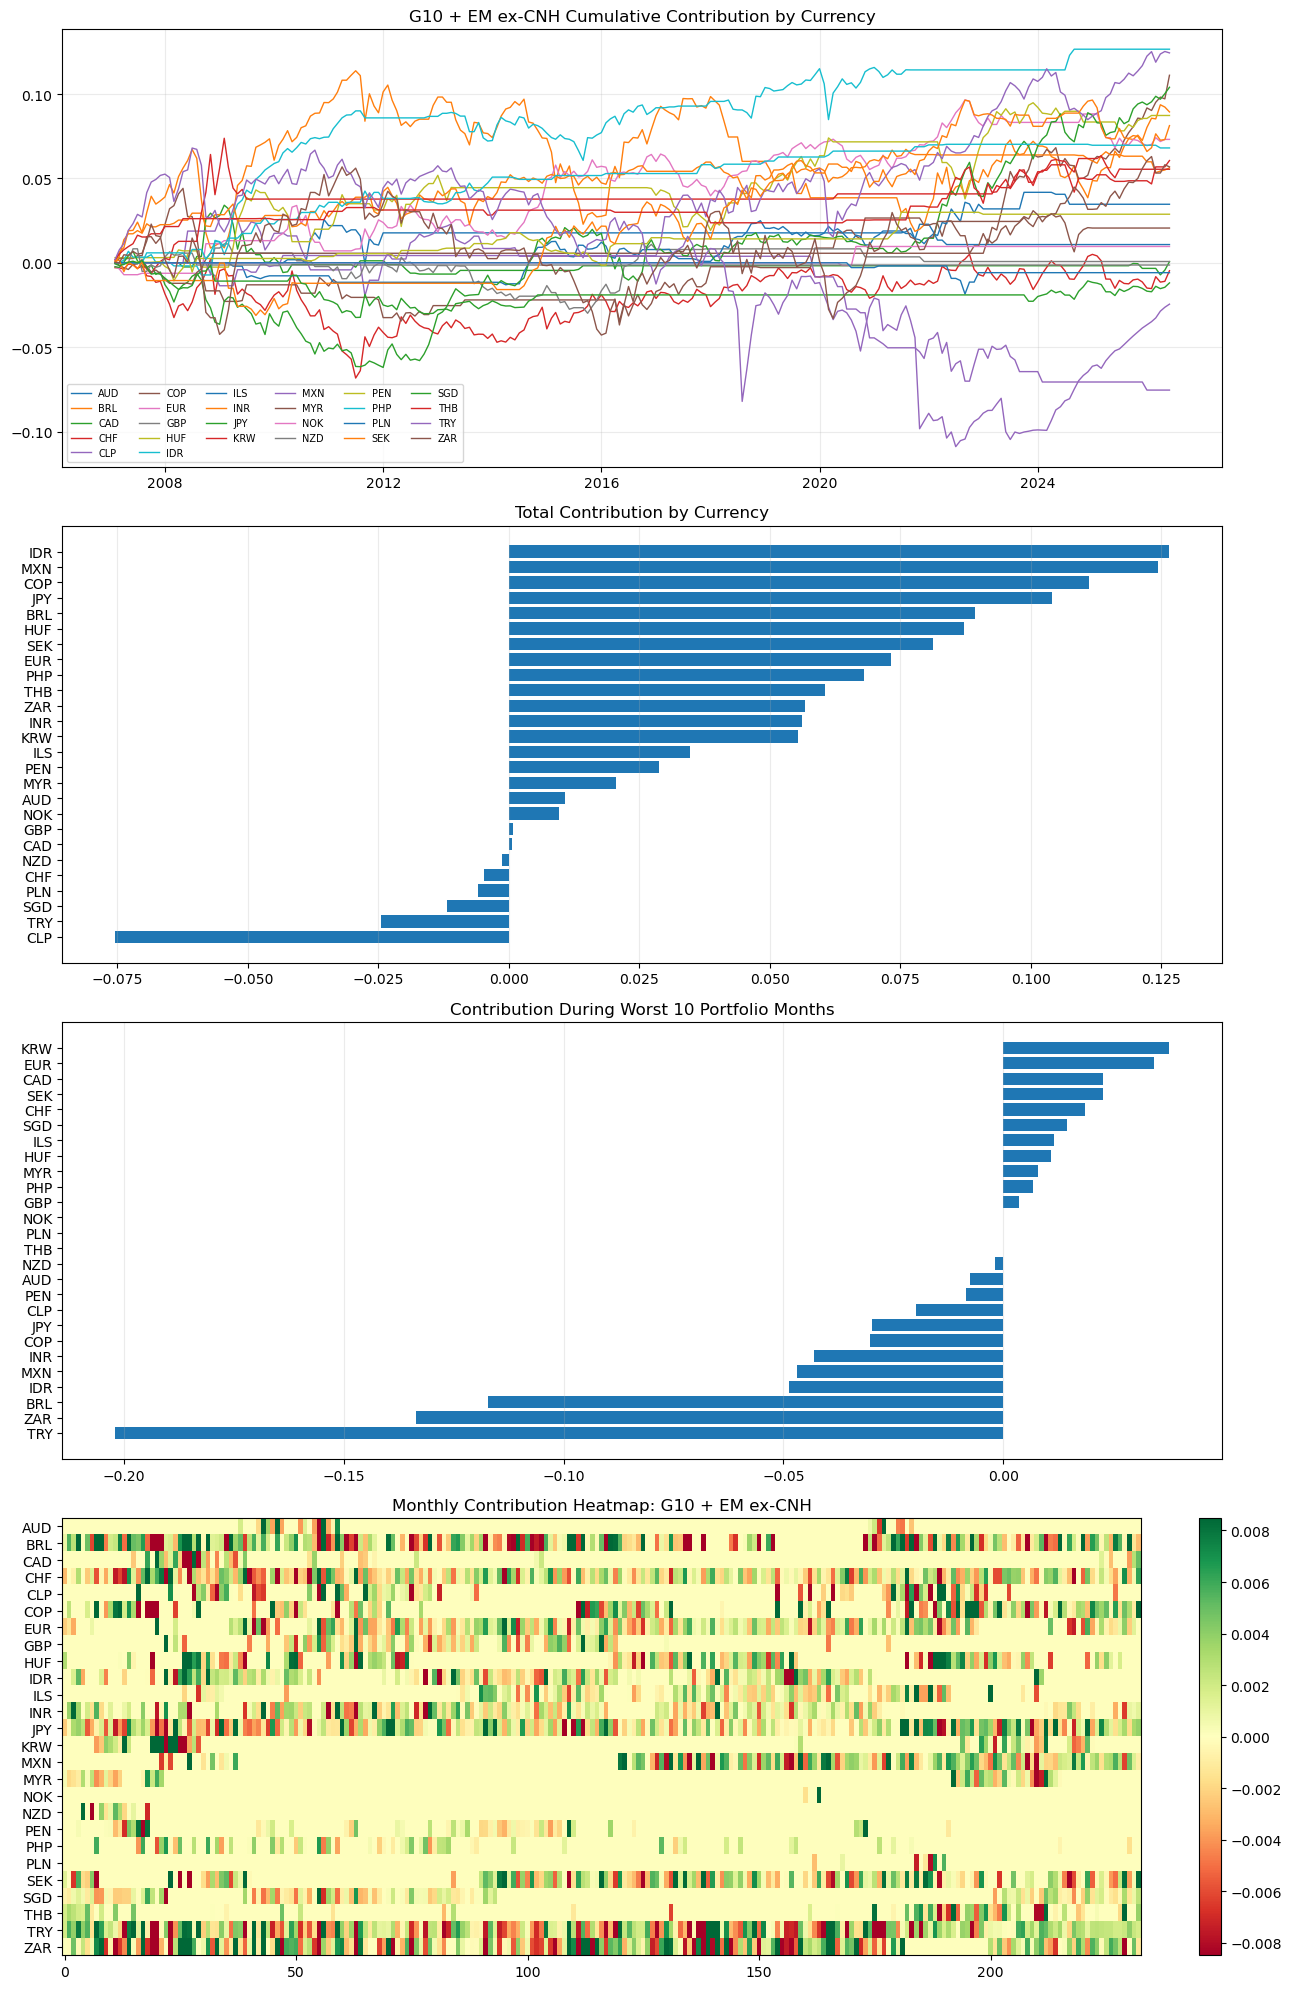

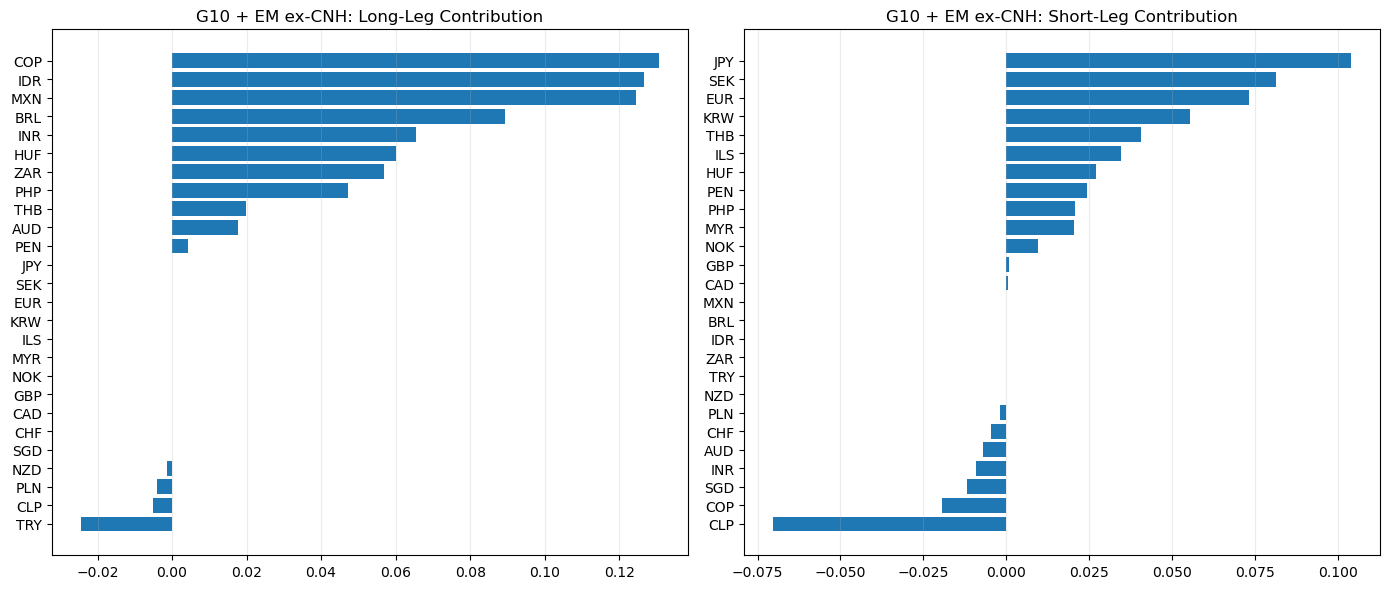

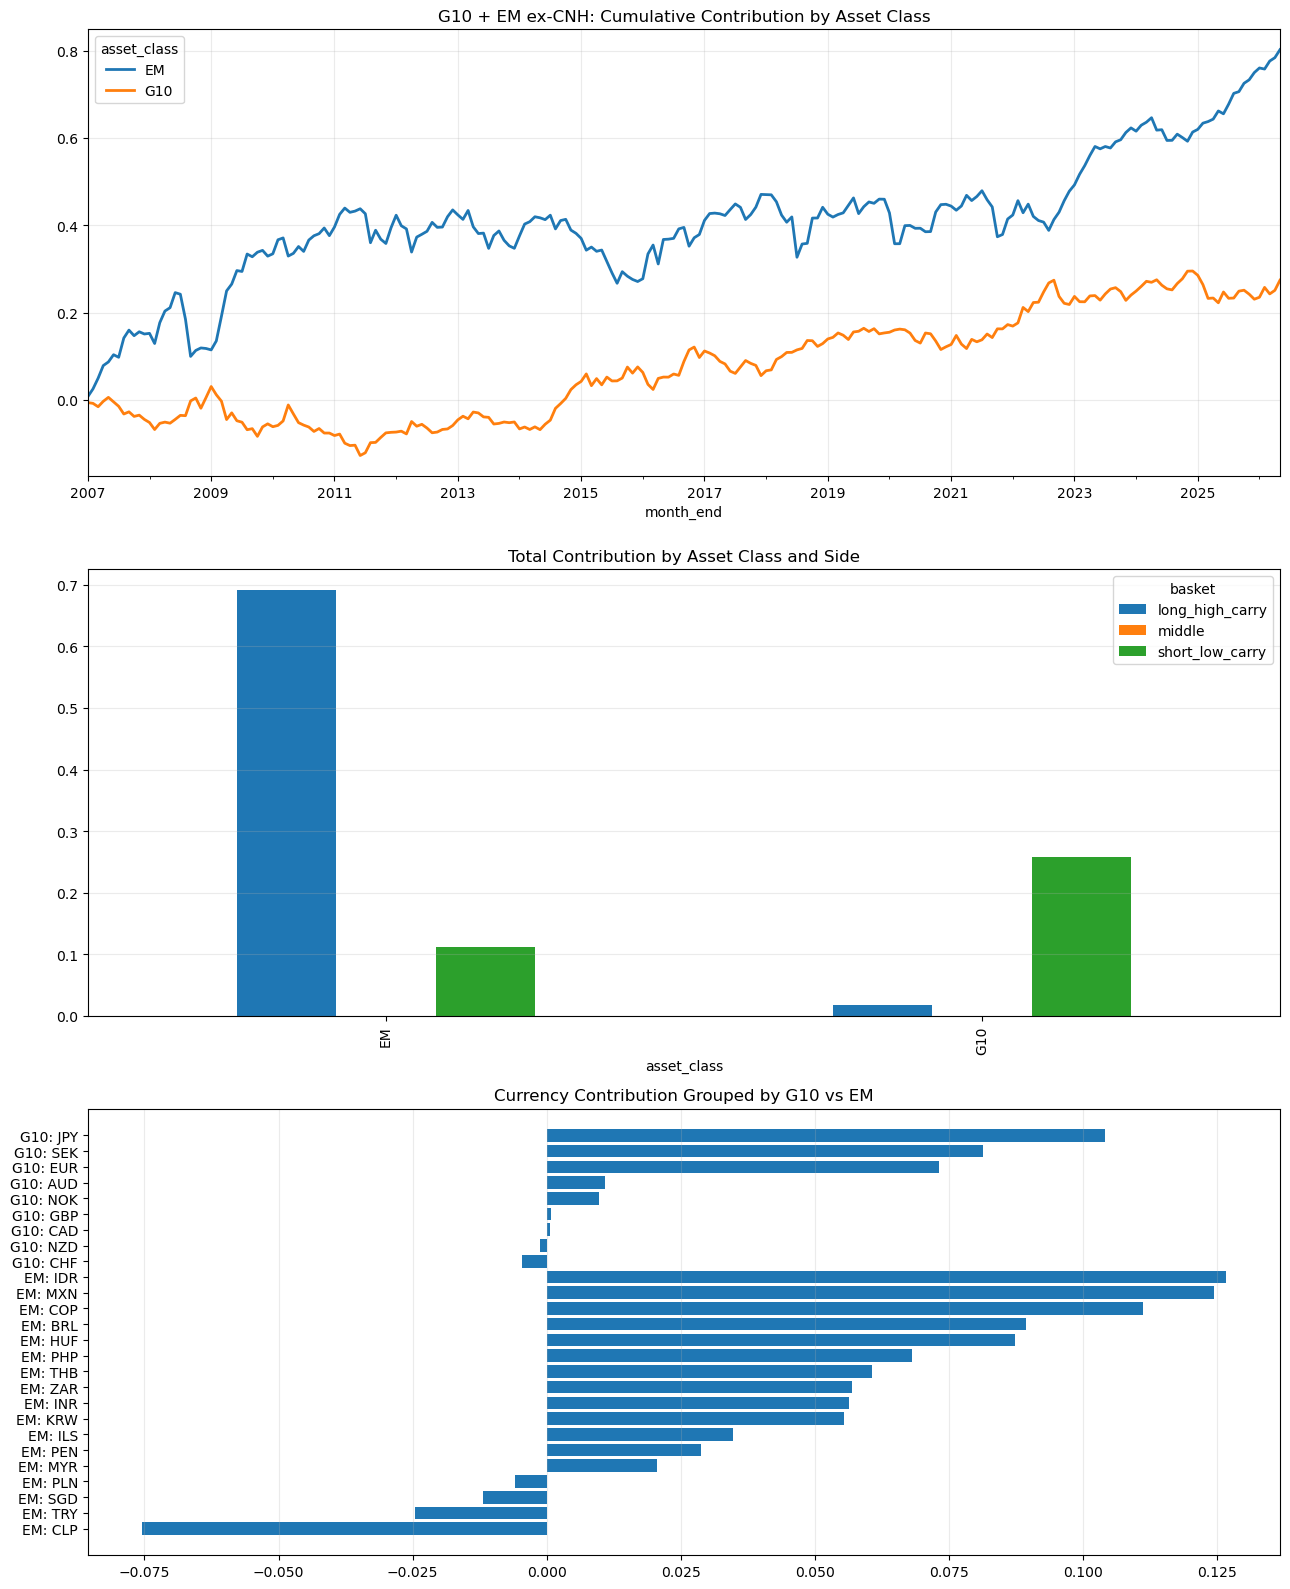

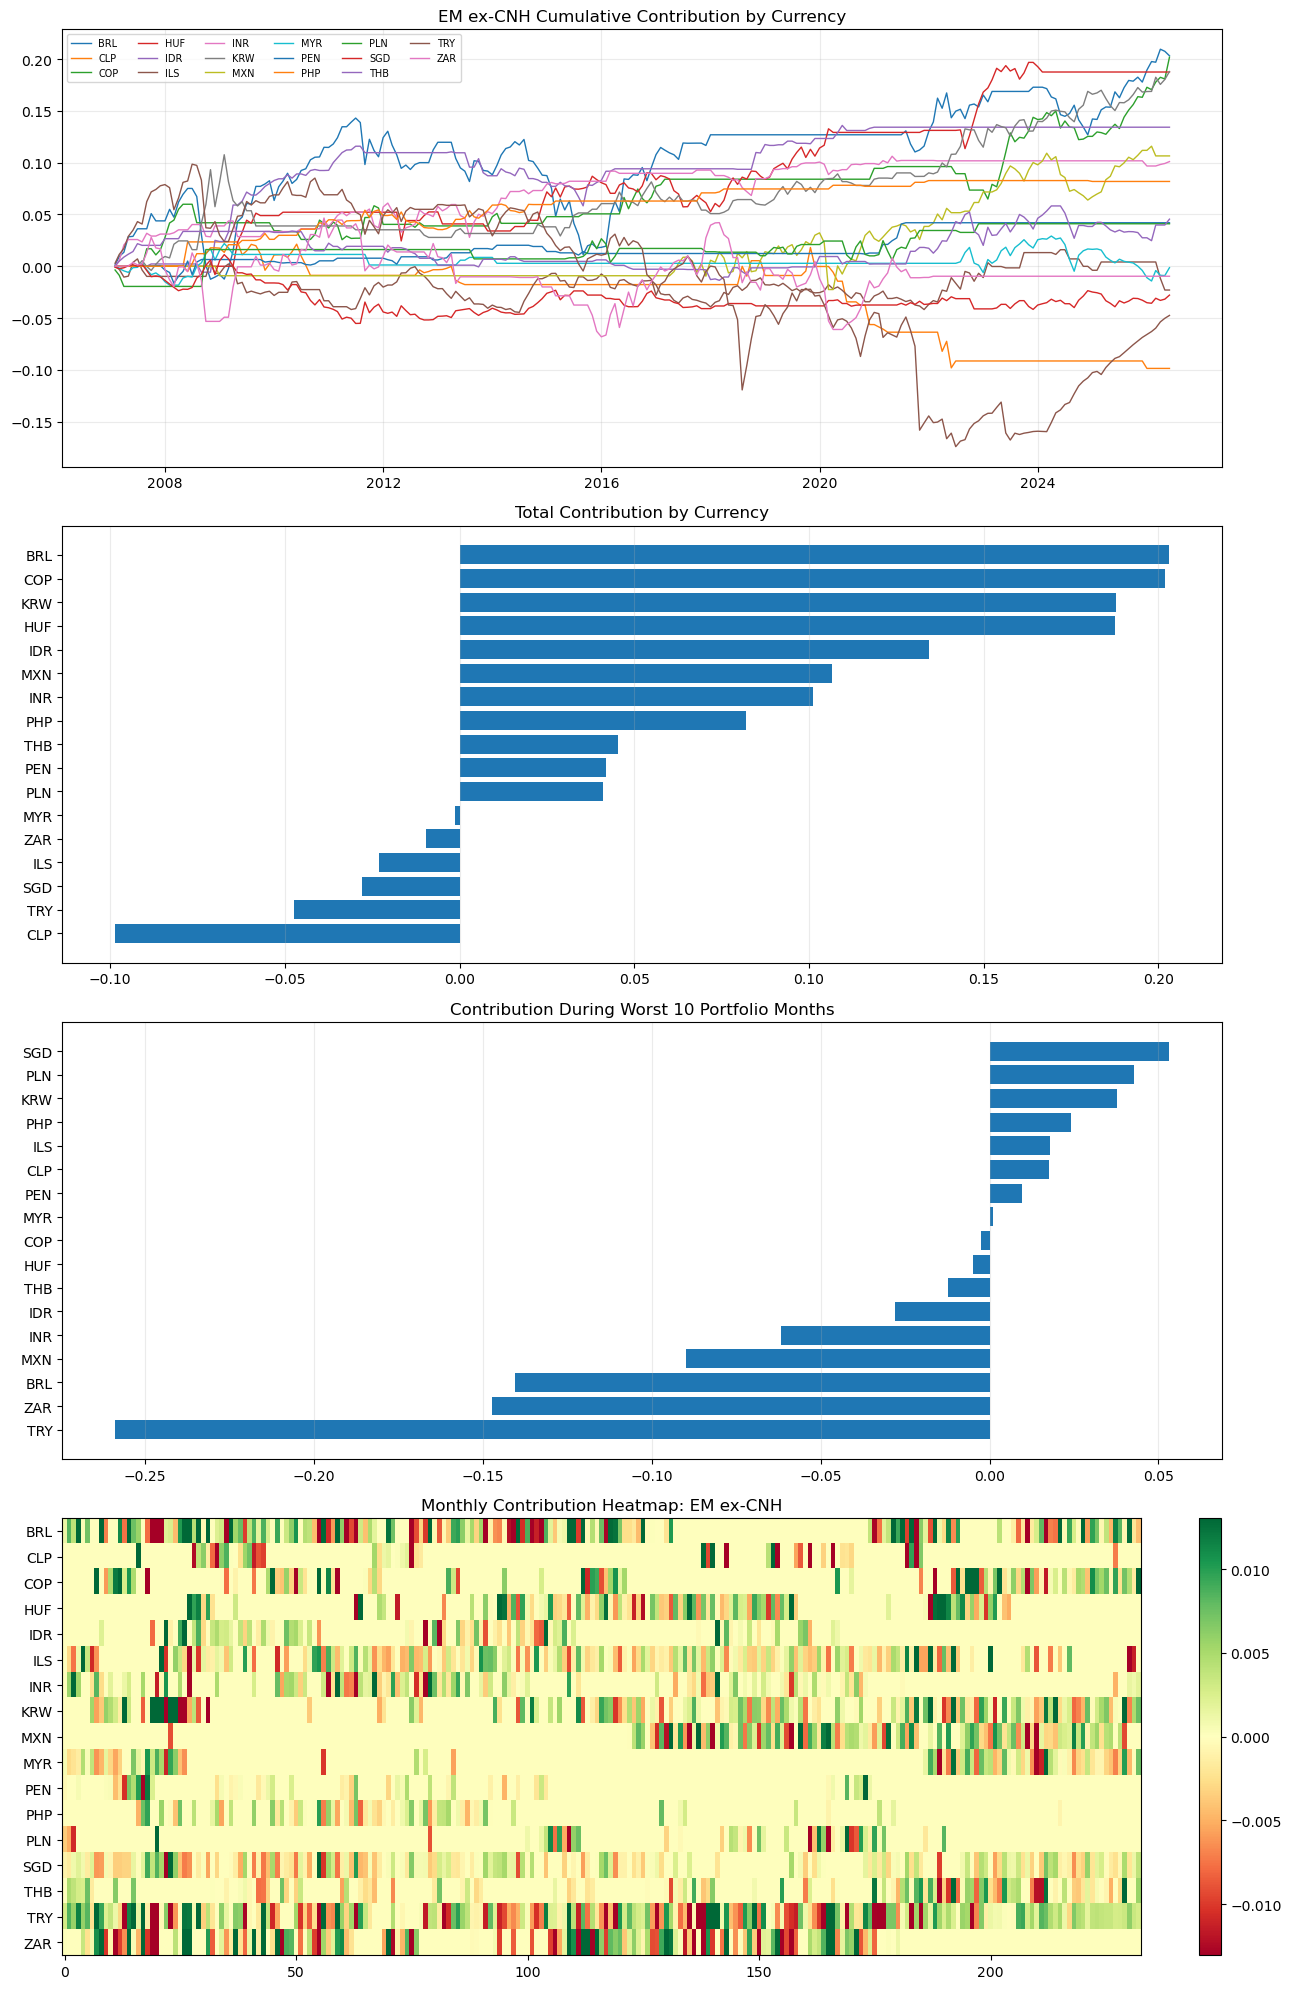

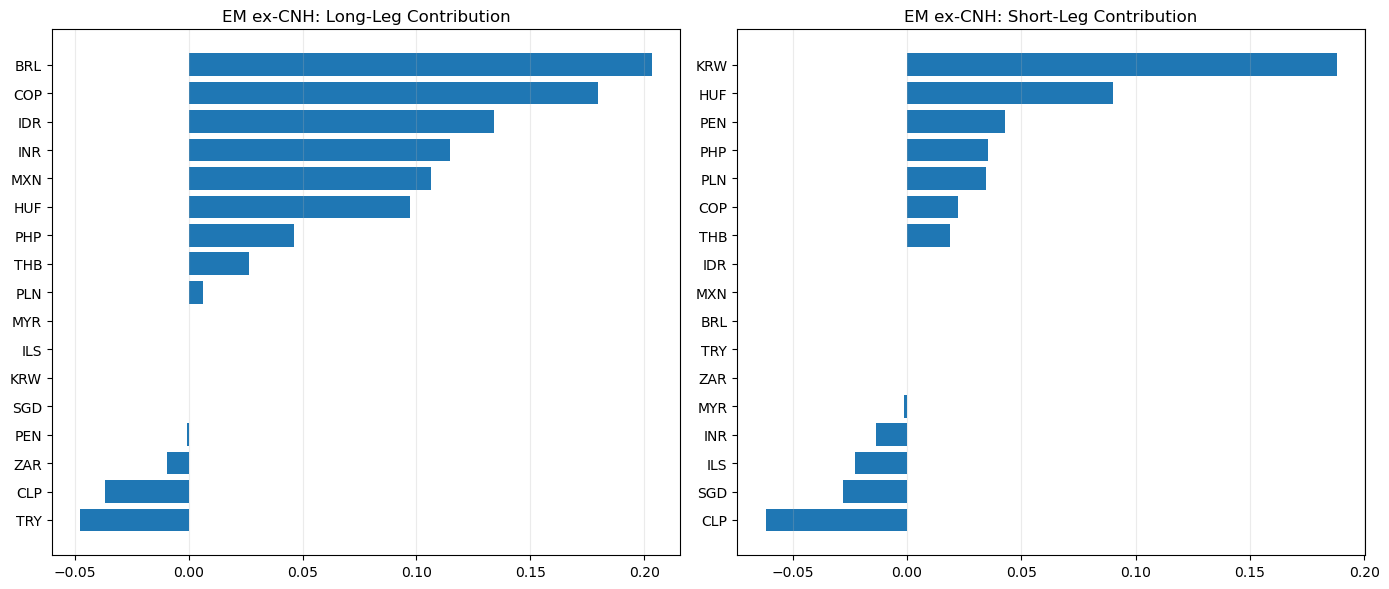

### Contribution summary: G10 + EM ex-CNH

Top positive contributors: IDR, MXN, COP, JPY, BRL. Largest worst-month detractors: TRY, ZAR, BRL, IDR, MXN.

,asset_class,currency,total_cumulative_contribution,annualized_contribution,contribution_worst10_months,long_side_contribution,short_side_contribution
53,EM,IDR,12.66%,0.65%,-4.87%,12.66%,0.00%
58,EM,MXN,12.44%,0.64%,-4.70%,12.44%,0.00%
49,EM,COP,11.11%,0.57%,-3.03%,13.06%,-1.94%
56,G10,JPY,10.40%,0.54%,-2.99%,0.00%,10.40%
45,EM,BRL,8.94%,0.46%,-11.71%,8.94%,0.00%
52,EM,HUF,8.73%,0.45%,1.08%,6.02%,2.72%
65,G10,SEK,8.13%,0.42%,2.26%,0.00%,8.13%
50,G10,EUR,7.31%,0.38%,3.43%,0.00%,7.31%
63,EM,PHP,6.81%,0.39%,0.67%,4.73%,2.08%
67,EM,THB,6.06%,0.31%,0.00%,1.99%,4.07%


### Contribution summary: EM ex-CNH

Top positive contributors: BRL, COP, KRW, HUF, IDR. Largest worst-month detractors: TRY, ZAR, BRL, MXN, INR.

,asset_class,currency,total_cumulative_contribution,annualized_contribution,contribution_worst10_months,long_side_contribution,short_side_contribution
0,EM,BRL,20.32%,1.05%,-14.05%,20.32%,0.00%
2,EM,COP,20.18%,1.04%,-0.24%,17.95%,2.23%
7,EM,KRW,18.79%,0.97%,3.77%,0.00%,18.79%
3,EM,HUF,18.75%,0.97%,-0.49%,9.72%,9.03%
4,EM,IDR,13.42%,0.69%,-2.80%,13.42%,0.00%
8,EM,MXN,10.65%,0.55%,-8.98%,10.65%,0.00%
6,EM,INR,10.10%,0.52%,-6.17%,11.47%,-1.37%
11,EM,PHP,8.18%,0.46%,2.42%,4.63%,3.56%
14,EM,THB,4.55%,0.23%,-1.23%,2.66%,1.88%
10,EM,PEN,4.20%,0.22%,0.96%,-0.07%,4.27%


In [214]:
def display_contribution_tables(strategy):
    sub = contribution_summary[contribution_summary["strategy"].eq(strategy)].sort_values("total_cumulative_contribution", ascending=False)
    if sub.empty:
        display(Markdown(f"No contribution summary available for **{strategy}**."))
        return
    display(Markdown(f"### Contribution summary: {strategy}"))
    display(Markdown(
        f"Top positive contributors: {', '.join(sub.head(5)['currency'])}. "
        f"Largest worst-month detractors: {', '.join(sub.sort_values('contribution_worst10_months').head(5)['currency'])}."
    ))
    cols = ["asset_class", "currency", "total_cumulative_contribution", "annualized_contribution", "contribution_worst10_months", "long_side_contribution", "short_side_contribution"]
    display(sub[cols].style.format({
        "total_cumulative_contribution":"{:.2%}",
        "annualized_contribution":"{:.2%}",
        "contribution_worst10_months":"{:.2%}",
        "long_side_contribution":"{:.2%}",
        "short_side_contribution":"{:.2%}",
    }))

if plt is None or contribution_panel.empty:
    display(Markdown("Contribution plots skipped."))
else:
    for plot_strategy in VALID_ATTRIBUTION_STRATEGIES_TO_PLOT:
        main = contribution_panel[contribution_panel["strategy"].eq(plot_strategy)].copy()
        if main.empty:
            warnings.warn(f"No contribution data available for {plot_strategy}; skipping contribution plots.")
            continue
        main["cum_contribution"] = main.groupby("currency")["contribution"].cumsum()
        pivot = main.pivot_table(index="month_end", columns="currency", values="contribution", aggfunc="sum").fillna(0.0).sort_index()
        cumpivot = pivot.cumsum()
        fig, axes = plt.subplots(4, 1, figsize=(13, 20))
        for ccy in cumpivot.columns:
            axes[0].plot(cumpivot.index, cumpivot[ccy], label=ccy, linewidth=1.0)
        axes[0].set_title(f"{plot_strategy} Cumulative Contribution by Currency")
        axes[0].legend(ncol=6, fontsize=7)
        axes[0].grid(alpha=0.25)

        top_contrib = contribution_summary[contribution_summary["strategy"].eq(plot_strategy)].sort_values("total_cumulative_contribution")
        axes[1].barh(top_contrib["currency"], top_contrib["total_cumulative_contribution"])
        axes[1].set_title("Total Contribution by Currency")

        worst = contribution_summary[contribution_summary["strategy"].eq(plot_strategy)].sort_values("contribution_worst10_months")
        axes[2].barh(worst["currency"], worst["contribution_worst10_months"])
        axes[2].set_title("Contribution During Worst 10 Portfolio Months")

        if len(pivot) and len(pivot.columns):
            lim = np.nanpercentile(np.abs(pivot.values), 95)
            lim = lim if np.isfinite(lim) and lim > 0 else 1e-6
            im = axes[3].imshow(pivot.T, aspect="auto", cmap="RdYlGn", vmin=-lim, vmax=lim)
            axes[3].set_yticks(range(len(pivot.columns)))
            axes[3].set_yticklabels(pivot.columns)
            fig.colorbar(im, ax=axes[3], orientation="vertical", fraction=0.02)
        axes[3].set_title(f"Monthly Contribution Heatmap: {plot_strategy}")
        for ax in axes[1:3]:
            ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()

        leg = contribution_summary[contribution_summary["strategy"].eq(plot_strategy)].sort_values("long_side_contribution")
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].barh(leg["currency"], leg["long_side_contribution"])
        axes[0].set_title(f"{plot_strategy}: Long-Leg Contribution")
        leg2 = contribution_summary[contribution_summary["strategy"].eq(plot_strategy)].sort_values("short_side_contribution")
        axes[1].barh(leg2["currency"], leg2["short_side_contribution"])
        axes[1].set_title(f"{plot_strategy}: Short-Leg Contribution")
        for ax in axes:
            ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()

        if plot_strategy == PRIMARY_ATTRIBUTION_STRATEGY and "asset_class" in main.columns:
            asset_month = main.groupby(["month_end", "asset_class"], as_index=False)["contribution"].sum()
            asset_pivot = asset_month.pivot(index="month_end", columns="asset_class", values="contribution").fillna(0.0).sort_index()
            asset_side = main.groupby(["asset_class", "basket"], as_index=False)["contribution"].sum()
            currency_asset = contribution_summary[contribution_summary["strategy"].eq(plot_strategy)].copy()
            currency_asset["currency_label"] = currency_asset["asset_class"] + ": " + currency_asset["currency"]
            currency_asset = currency_asset.sort_values(["asset_class", "total_cumulative_contribution"])

            fig, axes = plt.subplots(3, 1, figsize=(13, 16))
            asset_pivot.cumsum().plot(ax=axes[0], linewidth=2)
            axes[0].set_title(f"{plot_strategy}: Cumulative Contribution by Asset Class")
            axes[0].grid(alpha=0.25)
            asset_side.pivot(index="asset_class", columns="basket", values="contribution").fillna(0.0).plot(kind="bar", ax=axes[1])
            axes[1].set_title("Total Contribution by Asset Class and Side")
            axes[1].grid(axis="y", alpha=0.25)
            axes[2].barh(currency_asset["currency_label"], currency_asset["total_cumulative_contribution"])
            axes[2].set_title("Currency Contribution Grouped by G10 vs EM")
            axes[2].grid(axis="x", alpha=0.25)
            plt.tight_layout()
            plt.show()

for strategy in VALID_ATTRIBUTION_STRATEGIES_TO_PLOT:
    display_contribution_tables(strategy)
